# 03 — Fill-Aware Anti-Windup Residual Dual (D3)

This notebook is the **single predeclared D3 development-validation experiment** motivated by the frozen v0.9 saturation diagnosis.

## Scientific question

Can a bounded, episode-local residual controller improve absolute inventory-budget control when it is added to the already stable K4 fixed-penalty backbone, without collapsing trading activity?

## Matched arms

| Label | Frozen K4 backbone | Residual pacing | Fill-aware alarm | Anti-windup |
|---|---:|---:|---:|---:|
| `D3A_K4_CONTINUATION` | yes | no | no | n/a |
| `D3B_RESIDUAL_PACING` | yes | yes | no | yes |
| `D3C_FILL_AWARE_ANTI_WINDUP` | yes | yes | yes | yes |

`D3C_FILL_AWARE_ANTI_WINDUP` is the sole proposed method. The primary incremental contrast is D3C minus D3B. D3C minus D3A tests the complete adaptive correction.

## Frozen protocol

- source: the seed-matched K4 episode-10 checkpoints from v0.8;
- five seeds and five additional 30-minute training episodes per arm;
- each heavy training cell commits at most one new episode and is safely rerunnable;
- each heavy validation cell commits at most one new window and is safely rerunnable;
- identical post-K4 training-start streams within every seed;
- the same seven development-validation windows as v0.8/v0.9;
- no checkpoint selection, controller search, fixed-penalty retuning, test access, or OOS access;
- train-only calibration of the outstanding-order conversion factor from frozen D2 training traces;
- crossed seed × window bootstrap, moving-block sensitivity and seed-level intervals;
- all outcomes are frozen for the article, including negative or nuanced outcomes.

The seven validation windows have already informed method development through D2. They are therefore **development validation**, not a fresh independent OOS sample. A future untouched OOS run may be authorized only by the final gate.


In [ ]:
from google.colab import drive
from pathlib import Path
import os, sys

MOUNT = Path("/content/drive")
if not (MOUNT / "MyDrive").exists():
    drive.mount(str(MOUNT))

PROJECT_ROOT = Path(
    os.environ.get("RIMM_PROJECT_ROOT", MOUNT / "MyDrive" / "RIMM")
)
if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)


In [ ]:
import copy
import gc
import hashlib
import inspect
import json
import math
import os
import random
import subprocess
import time
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn.functional as F
import yaml
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


## 1. Frozen configuration

The K4 penalty remains the non-adaptive backbone. D3 only adds a non-negative residual multiplier that is reset to zero at the beginning of every episode.

For controller block (m),

\[
d_m=\frac{\Delta C_m-\Delta B_m}{\Delta B_m+\varepsilon},
\qquad
\bar d_m=(1-\beta)\bar d_{m-1}+\beta\,\operatorname{clip}(d_m,-2,2).
\]

The proposed arm adds a selective train-calibrated alarm (a_m). The bounded PI-like residual update is

\[
\delta_{m+1}=\Pi_{[0,\delta_{max}]}
\left((1-\omega)\delta_m+\eta_I(\bar d_m+\alpha a_m)
+\eta_P(\bar d_m-\bar d_{m-1})\right),
\]

with conditional integration when the proposed step would saturate. The effective normalized penalty is

\[
\lambda_m^{eff}=\lambda_{K4}+\delta_m.
\]


In [ ]:
SEED = 42
SYMBOL = "ETHUSDT"
RUN_PROFILE = "fill_aware_anti_windup_residual_dual"
SPEC_ID = "v10_d3_fill_aware_residual_dual_20261005"

MASTER_SEEDS = (10801, 10802, 10803, 10804, 10805)
ARMS = {
    "D3A_K4_CONTINUATION": dict(residual=False, fill_aware=False),
    "D3B_RESIDUAL_PACING": dict(residual=True, fill_aware=False),
    "D3C_FILL_AWARE_ANTI_WINDUP": dict(residual=True, fill_aware=True),
}
ARM_LABELS = tuple(ARMS)
PROPOSED_LABEL = "D3C_FILL_AWARE_ANTI_WINDUP"
PACING_LABEL = "D3B_RESIDUAL_PACING"
CONTROL_LABEL = "D3A_K4_CONTINUATION"
SOURCE_CHECKPOINT_EPISODE = 10
BRANCH_EPISODES = 5
PRIMARY_BRANCH_EPISODE = 5

TRAIN_EPISODE_MINUTES = 30.0
EVAL_EPISODE_MINUTES = 30.0
DECISION_INTERVAL_MS = 500
EXPECTED_HORIZON_STEPS = int(round(EVAL_EPISODE_MINUTES * 60_000 / DECISION_INTERVAL_MS))

TRAIN_CFG = dict(
    replay_capacity=150_000,
    batch_size=256,
    gamma=0.999,
    gamma_cost=0.999,
    tau=0.005,
    policy_delay=2,
    target_noise=0.2,
    noise_clip=0.5,
    exploration_noise=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    encoder_lr=3e-4,
    cost_critic_lr=3e-4,
    update_every=2,
)
IMM_CFG = dict(
    expert_critic_batch_size=128,
    expert_actor_batch_size=256,
    bc_weight_0=1.0,
    imitation_decay_fraction=0.40,
)
D3_CFG = dict(
    branch_episodes=BRANCH_EPISODES,
    snapshot_episodes=(3, 5),
    bootstrap_samples=20_000,
    moving_block_length=2,
    activity_floor_fraction=0.50,
    controller_block_steps=120,
    controller_error_clip=2.0,
    ema_beta=0.25,
    leakage=0.05,
    proportional_fraction=0.50,
    residual_max_multiple=1.0,
    alarm_gain=0.25,
    fill_conversion_quantile=0.75,
    fill_conversion_floor=0.05,
    alarm_threshold_quantile=0.75,
    cost_critic_warmup_updates=1_000,
    max_residual_cap_fraction=0.50,
    max_new_episodes_per_call=1,
    max_new_windows_per_call=1,
)
RISK_CFG = dict(gamma_cost=TRAIN_CFG["gamma_cost"], reference_band_N=3.0)
EXPECTED_UPDATES = 22_500
CONTEXT_DIM = 5
BASE_PRIVATE_DIM = 21
AUG_PRIVATE_DIM = BASE_PRIVATE_DIM + CONTEXT_DIM
BASE_STATE_DIM = 89
AUG_STATE_DIM = BASE_STATE_DIM + CONTEXT_DIM

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(json.dumps({
    "spec_id": SPEC_ID,
    "source_checkpoint_episode": SOURCE_CHECKPOINT_EPISODE,
    "additional_training_episodes": BRANCH_EPISODES,
    "seeds": MASTER_SEEDS,
    "arms": ARM_LABELS,
    "proposed": PROPOSED_LABEL,
    "test_accessed": False,
}, indent=2))


{
  "spec_id": "v10_d3_fill_aware_residual_dual_20261005",
  "source_checkpoint_episode": 10,
  "additional_training_episodes": 5,
  "seeds": [
    10801,
    10802,
    10803,
    10804,
    10805
  ],
  "arms": [
    "D3A_K4_CONTINUATION",
    "D3B_RESIDUAL_PACING",
    "D3C_FILL_AWARE_ANTI_WINDUP"
  ],
  "proposed": "D3C_FILL_AWARE_ANTI_WINDUP",
  "test_accessed": false
}


## 2. Frozen project components, data loader and continuity environment


In [ ]:
from mmrl.imm.environment import IMMMarketData, IMMMarketMakingEnv, IMMRewardConfig
from mmrl.imm.tcsa import IMMTCSAEncoder, IMMStateEncoder, TD3Actor, TD3TwinCritic
from mmrl.imm.td3 import clipped_target_action, polyak_update, reconstruct_market_batch
from mmrl.imm.reward import NotionalBpsReward
from mmrl.imm.risk_budget import InventoryExposureCost, RiskIndexedReplayBuffer
from mmrl.simulator import ReplaySimulator
from mmrl.imm.grid import price_tick_to_grid_level

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DIR = PROJECT_ROOT / "artifacts" / "splits"
SIGNAL_DIR = PROJECT_ROOT / "artifacts" / "imm_predictive_signals"
EXPERT_DIR = PROJECT_ROOT / "artifacts" / "imm_expert_bc"

with open(PROJECT_ROOT / "configs" / "data.yaml", "r", encoding="utf-8") as f:
    DATA_CFG = yaml.safe_load(f)
with open(PROJECT_ROOT / "configs" / "simulator.yaml", "r", encoding="utf-8") as f:
    SIM_CFG = yaml.safe_load(f)

OFFSETS_MS = DATA_CFG["trade_alignment_offset_ms"]
MAX_GAP_MS = int(SIM_CFG["max_gap_ms"])
QUOTE_SIZE = {
    "BTCUSDT": 0.08220875,
    "ETHUSDT": 1.2455625,
    "BNBUSDT": 0.9417,
    "LTCUSDT": 3.8242,
}

ECONOMIC_REWARD_FN = NotionalBpsReward(
    beta=0.01,
    eta=0.0,
    inventory_threshold_N=3.0,
)
RISK_COST_FN = InventoryExposureCost(reference_band_N=RISK_CFG["reference_band_N"])


In [ ]:
def infer_tick_size(states):
    gaps = []
    for i in range(1, 5):
        gaps.append(
            states[f"ask_price_{i+1}"].to_numpy(float)
            - states[f"ask_price_{i}"].to_numpy(float)
        )
        gaps.append(
            states[f"bid_price_{i}"].to_numpy(float)
            - states[f"bid_price_{i+1}"].to_numpy(float)
        )

    x = np.concatenate(gaps)
    x = x[np.isfinite(x) & (x > 0)]
    values, counts = np.unique(np.round(x, 10), return_counts=True)
    return float(values[np.argmax(counts)])


def normalize_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(np.int8).astype(bool)

    mapping = {
        "true": True, "1": True, "t": True, "yes": True,
        "false": False, "0": False, "f": False, "no": False,
    }
    out = series.astype(str).str.lower().str.strip().map(mapping)
    if out.isna().any():
        raise ValueError("unknown boolean value")
    return out.astype(bool)


def load_asset(symbol):
    state_path = PROCESSED_DIR / symbol / "states.parquet"
    split_path = SPLIT_DIR / f"{symbol.lower()}_state_splits.parquet"
    trade_path = RAW_DIR / symbol / "trades.parquet"
    signal_path = SIGNAL_DIR / symbol / "signals.parquet"
    demo_path = EXPERT_DIR / symbol / "expert_demonstrations.parquet"

    state_cols = ["local_timestamp", "mid_price"]
    for side in ["bid", "ask"]:
        for i in range(1, 6):
            state_cols += [f"{side}_price_{i}", f"{side}_qty_{i}"]

    states = (
        pd.read_parquet(state_path, columns=state_cols)
        .sort_values("local_timestamp", kind="stable")
        .reset_index(drop=True)
    )
    split = (
        pd.read_parquet(split_path)
        .sort_values("local_timestamp", kind="stable")
        .reset_index(drop=True)
    )
    signals_df = (
        pd.read_parquet(signal_path)
        .sort_values("local_timestamp", kind="stable")
        .reset_index(drop=True)
    )

    if not np.array_equal(
        pd.to_numeric(states["local_timestamp"]).to_numpy(np.int64),
        pd.to_numeric(signals_df["local_timestamp"]).to_numpy(np.int64),
    ):
        raise ValueError(f"{symbol}: signal timestamp mismatch")

    tick_size = infer_tick_size(states)
    schema = pq.ParquetFile(trade_path).schema.names

    if "timestamp_us" in schema:
        ts_col, multiplier = "timestamp_us", 1
    elif "timestamp_ms" in schema:
        ts_col, multiplier = "timestamp_ms", 1000
    else:
        raise ValueError(f"{symbol}: missing trade timestamp")

    trades = pd.read_parquet(
        trade_path,
        columns=[ts_col, "price", "qty", "is_buyer_maker"],
    ).copy()
    trades["effective_timestamp_us"] = (
        pd.to_numeric(trades[ts_col]).astype(np.int64)
        * int(multiplier)
        + int(OFFSETS_MS[symbol]) * 1000
    )
    trades["price"] = pd.to_numeric(trades["price"]).astype(float)
    trades["qty"] = pd.to_numeric(trades["qty"]).astype(float)
    trades["is_buyer_maker"] = normalize_bool(trades["is_buyer_maker"])
    trades = (
        trades[["effective_timestamp_us", "price", "qty", "is_buyer_maker"]]
        .sort_values("effective_timestamp_us", kind="stable")
        .reset_index(drop=True)
    )

    data = IMMMarketData(
        symbol=symbol,
        states=states,
        split=split,
        trades=trades,
        quote_size=QUOTE_SIZE[symbol],
        tick_size=tick_size,
        lookback=64,
    )

    signals = signals_df[
        ["signal_10s", "signal_60s", "signal_120s", "signal_300s"]
    ].to_numpy(np.float32)
    ready = signals_df["signal_ready"].to_numpy(bool)

    demos = (
        pd.read_parquet(demo_path)
        .sort_values("timestamp_ms", kind="stable")
        .reset_index(drop=True)
    )
    return data, signals, ready, demos


In [ ]:
class ContinuityIMMMarketMakingEnv(IMMMarketMakingEnv):
    def _cancel_offgrid_orders_at_current_decision(self):
        if self.idx is None:
            raise RuntimeError("env not reset")

        ref2 = int(self.data.ref2[int(self.idx)])
        active_orders = list(self.simulator.order_manager.active_orders)
        offgrid_orders = [
            order
            for order in active_orders
            if price_tick_to_grid_level(
                ref2,
                int(order.price_tick),
                k=5,
            ) is None
        ]

        canceled_qty = 0.0
        for order in offgrid_orders:
            canceled_qty += float(
                self.simulator.order_manager.cancel_order(int(order.order_id))
            )

        obs, private_info = self._observation()
        return (
            obs.as_dict(),
            private_info,
            int(len(offgrid_orders)),
            float(canceled_qty),
        )

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)

        before_count = int(info["offgrid_live_child_count"])
        before_qty = float(info["offgrid_live_qty"])

        (
            repaired_obs,
            private_info,
            canceled_count,
            canceled_qty,
        ) = self._cancel_offgrid_orders_at_current_decision()

        if canceled_count != before_count:
            raise AssertionError(
                f"reflection/direct off-grid count mismatch: "
                f"{before_count} vs {canceled_count}"
            )

        info.update(private_info)
        info["offgrid_live_child_count_before_auto_cancel"] = before_count
        info["offgrid_live_qty_before_auto_cancel"] = before_qty
        info["offgrid_auto_canceled_count"] = canceled_count
        info["offgrid_auto_canceled_qty"] = canceled_qty
        info["offgrid_live_child_count_after_auto_cancel"] = int(
            private_info["offgrid_live_child_count"]
        )
        info["offgrid_live_qty_after_auto_cancel"] = float(
            private_info["offgrid_live_qty"]
        )
        info["canceled_qty"] = float(info["canceled_qty"]) + canceled_qty

        if info["offgrid_live_child_count_after_auto_cancel"] != 0:
            raise AssertionError("off-grid order survived auto-cancel")

        return repaired_obs, reward, terminated, truncated, info


In [ ]:
@dataclass
class RiskBundle:
    se: torch.nn.Module
    actor: torch.nn.Module
    reward_critics: torch.nn.Module
    cost_critics: torch.nn.Module
    tse: torch.nn.Module
    tactor: torch.nn.Module
    treward_critics: torch.nn.Module
    tcost_critics: torch.nn.Module
    se_opt: torch.optim.Optimizer
    actor_opt: torch.optim.Optimizer
    reward_critics_opt: torch.optim.Optimizer
    cost_critics_opt: torch.optim.Optimizer


def make_bundle(cfg=TRAIN_CFG):
    market_encoder = IMMTCSAEncoder(
        feature_dim=20,
        lookback=64,
        latent_dim=64,
        tcn_hidden_channels=64,
        tcn_kernel_size=3,
        tcn_dilations=(1, 2, 4),
        tcn_dropout=0.0,
    )
    # The frozen encoder still receives the original 21 private variables.
    # Five controller variables are concatenated after encoding.
    se = IMMStateEncoder(market_encoder, signal_dim=4, private_dim=BASE_PRIVATE_DIM)
    actor = TD3Actor(AUG_STATE_DIM, action_dim=4, hidden_dims=(256, 256))
    reward_critics = TD3TwinCritic(AUG_STATE_DIM, action_dim=4, hidden_dims=(256, 256))
    cost_critics = TD3TwinCritic(AUG_STATE_DIM, action_dim=4, hidden_dims=(256, 256))

    tse = copy.deepcopy(se)
    tactor = copy.deepcopy(actor)
    treward_critics = copy.deepcopy(reward_critics)
    tcost_critics = copy.deepcopy(cost_critics)

    modules = [se, actor, reward_critics, cost_critics,
               tse, tactor, treward_critics, tcost_critics]
    modules = [m.to(DEVICE) for m in modules]
    se, actor, reward_critics, cost_critics, tse, tactor, treward_critics, tcost_critics = modules
    for module in [tse, tactor, treward_critics, tcost_critics]:
        module.eval()
        for p in module.parameters():
            p.requires_grad_(False)

    return RiskBundle(
        se=se, actor=actor, reward_critics=reward_critics, cost_critics=cost_critics,
        tse=tse, tactor=tactor, treward_critics=treward_critics,
        tcost_critics=tcost_critics,
        se_opt=torch.optim.Adam(se.parameters(), lr=cfg["encoder_lr"]),
        actor_opt=torch.optim.Adam(actor.parameters(), lr=cfg["actor_lr"]),
        reward_critics_opt=torch.optim.Adam(
            reward_critics.parameters(), lr=cfg["critic_lr"]
        ),
        cost_critics_opt=torch.optim.Adam(
            cost_critics.parameters(), lr=cfg["cost_critic_lr"]
        ),
    )


def _load_with_zero_expansion(module, source_state, name):
    target_state = module.state_dict()
    converted = {}
    for key, target in target_state.items():
        if key not in source_state:
            raise KeyError(f"{name}: missing source tensor {key}")
        source = source_state[key]
        if tuple(source.shape) == tuple(target.shape):
            converted[key] = source
        elif (source.ndim == target.ndim == 2
              and source.shape[0] == target.shape[0]
              and source.shape[1] < target.shape[1]):
            expanded = torch.zeros_like(target)
            expanded[:, :source.shape[1]] = source.to(expanded.device)
            converted[key] = expanded
        else:
            raise RuntimeError(
                f"{name}.{key}: unsupported expansion {tuple(source.shape)} -> {tuple(target.shape)}"
            )
    module.load_state_dict(converted, strict=True)


def load_shared_expanded_weights(bundle, payload):
    bundle.se.load_state_dict(payload["state_encoder"], strict=True)
    _load_with_zero_expansion(bundle.actor, payload["actor"], "actor")
    _load_with_zero_expansion(
        bundle.reward_critics, payload["reward_critics"], "reward_critics"
    )
    # The normalized cost critic is deliberately initialized from the same seed,
    # not imported from a critic trained on a different target scale.
    bundle.tse.load_state_dict(bundle.se.state_dict())
    bundle.tactor.load_state_dict(bundle.actor.state_dict())
    bundle.treward_critics.load_state_dict(bundle.reward_critics.state_dict())
    bundle.tcost_critics.load_state_dict(bundle.cost_critics.state_dict())
    return bundle


def make_simulator():
    return ReplaySimulator(
        max_gap_ms=MAX_GAP_MS,
        maker_fee_rate=0.0,
        allow_marketable_orders=bool(SIM_CFG["allow_marketable_orders"]),
        allow_inside_spread=bool(SIM_CFG["allow_inside_spread"]),
        allow_beyond_depth5=bool(SIM_CFG["allow_beyond_depth5"]),
        trade_through_fill=bool(SIM_CFG["trade_through_fill"]),
        allow_partial_fills=bool(SIM_CFG["allow_partial_fills"]),
    )


def make_env(data, signals, seed, episode_minutes=TRAIN_EPISODE_MINUTES):
    return ContinuityIMMMarketMakingEnv(
        data=data,
        simulator=make_simulator(),
        decision_interval_ms=DECISION_INTERVAL_MS,
        episode_duration_minutes=float(episode_minutes),
        reward_config=IMMRewardConfig(mode="pnl"),
        signal_matrix=signals,
        seed=seed,
    )


def available_split_name(data, preferred):
    names = {str(x) for x in np.unique(data.split_name)}
    aliases = {"train": ["train"], "validation": ["validation", "val", "valid"], "test": ["test"]}
    for name in aliases.get(preferred, [preferred]):
        if name in names:
            return name
    raise RuntimeError(f"No {preferred!r} split. Available: {sorted(names)}")


def eligible_starts(env, ready, split_name):
    data_ = env.data
    candidate = np.flatnonzero(
        (data_.split_name == split_name) & data_.lookback_ready & ready
    ).astype(np.int64)
    n = len(data_.timestamp_ms)
    episode_right = np.empty(n, dtype=np.int64)
    segment_break = (
        (data_.episode_id[1:] != data_.episode_id[:-1])
        | (data_.split_name[1:] != data_.split_name[:-1])
    )
    left_edges = np.flatnonzero(np.r_[True, segment_break])
    right_edges = np.r_[left_edges[1:] - 1, n - 1]
    for left, right in zip(left_edges, right_edges):
        episode_right[left:right + 1] = right
    available = data_.timestamp_ms[episode_right[candidate]] - data_.timestamp_ms[candidate]
    out = candidate[available >= env.episode_duration_ms]
    if len(out) == 0:
        raise RuntimeError(f"no full-duration starts for split={split_name}")
    return out


In [ ]:
class RiskExpertSampler:
    def __init__(self, data, demos, reward_fn, cost_fn, seed=42):
        self.data = data
        self.rng = np.random.default_rng(seed)

        self.actor_df = demos[demos["bc_valid"]].reset_index(drop=True)
        self.critic_df = demos[demos["critic_valid"]].reset_index(drop=True)
        if len(self.actor_df) == 0 or len(self.critic_df) == 0:
            raise RuntimeError("empty expert subset")

        self.a_idx = self.actor_df["state_idx"].to_numpy(np.int64)
        self.a_private = self.actor_df[
            [f"private_{j}" for j in range(21)]
        ].to_numpy(np.float32)
        self.a_action = self.actor_df[
            [f"expert_action_{j}" for j in range(4)]
        ].to_numpy(np.float32)

        self.c_idx = self.critic_df["state_idx"].to_numpy(np.int64)
        self.c_next = self.critic_df["next_state_idx"].to_numpy(np.int64)
        self.c_private = self.critic_df[
            [f"private_{j}" for j in range(21)]
        ].to_numpy(np.float32)
        self.c_next_private = self.critic_df[
            [f"next_private_{j}" for j in range(21)]
        ].to_numpy(np.float32)
        self.c_action = self.critic_df[
            [f"expert_action_{j}" for j in range(4)]
        ].to_numpy(np.float32)

        rewards, costs = [], []
        for row in self.critic_df.itertuples(index=False):
            reward, _ = reward_fn.compute(
                pnl=float(row.pnl),
                filled_notional=float(row.filled_notional),
                inventory=float(row.inventory_after),
                quote_size=float(data.quote_size),
                mid_price=float(data.mid_price[int(row.next_state_idx)]),
            )
            cost, _ = cost_fn.compute(
                inventory=float(row.inventory_after),
                quote_size=float(data.quote_size),
            )
            rewards.append(reward)
            costs.append(cost)

        self.c_reward = np.asarray(rewards, dtype=np.float32)
        self.c_cost = np.asarray(costs, dtype=np.float32)
        self.c_done = (
            data.episode_id[self.c_idx] != data.episode_id[self.c_next]
        ).astype(np.float32)

    def sample_actor(self, n):
        i = self.rng.integers(0, len(self.actor_df), size=int(n))
        return self.a_idx[i], self.a_private[i], self.a_action[i]

    def sample_critic(self, n):
        i = self.rng.integers(0, len(self.critic_df), size=int(n))
        return (
            self.c_idx[i],
            self.c_next[i],
            self.c_private[i],
            self.c_next_private[i],
            self.c_action[i],
            self.c_reward[i],
            self.c_cost[i],
            self.c_done[i],
        )


In [ ]:
def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def atomic_csv(frame, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    frame.to_csv(tmp, index=False); os.replace(tmp, path)


def atomic_parquet(frame, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    frame.to_parquet(tmp, index=False); os.replace(tmp, path)


def atomic_json(obj, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def atomic_torch_save(payload, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    torch.save(payload, tmp); os.replace(tmp, path)


def module_digest(*modules):
    h = hashlib.sha256()
    for module in modules:
        for name, tensor in sorted(module.state_dict().items()):
            h.update(name.encode("utf-8"))
            h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()


def set_grad(module, value):
    for p in module.parameters():
        p.requires_grad_(bool(value))


def bc_weight_at(global_gradient_step):
    decay_updates = max(1, round(IMM_CFG["imitation_decay_fraction"] * EXPECTED_UPDATES))
    return IMM_CFG["bc_weight_0"] * max(0.0, 1.0 - global_gradient_step / decay_updates)


def tensor_state(data_, signals_, idx, private_aug):
    idx = np.asarray(idx, np.int64)
    private_aug = np.asarray(private_aug, np.float32)
    if private_aug.shape[-1] != AUG_PRIVATE_DIM:
        raise ValueError(f"expected augmented private dim {AUG_PRIVATE_DIM}, got {private_aug.shape}")
    market = reconstruct_market_batch(data_.market_features, idx, lookback=64)
    signal = signals_[idx].astype(np.float32)
    return (
        torch.from_numpy(market).to(DEVICE),
        torch.from_numpy(signal).to(DEVICE),
        torch.from_numpy(private_aug[..., :BASE_PRIVATE_DIM]).to(DEVICE),
        torch.from_numpy(private_aug[..., BASE_PRIVATE_DIM:]).to(DEVICE),
    )


def encode_augmented(encoder, market, signal, private_base, context):
    base = encoder(market, signal, private_base)
    if base.shape[-1] != BASE_STATE_DIM or context.shape[-1] != CONTEXT_DIM:
        raise RuntimeError((base.shape, context.shape))
    return torch.cat([base, context], dim=-1)


def reconstruct_batch(data_, signals_, batch):
    market, sig, private, context = tensor_state(
        data_, signals_, batch["state_idx"], batch["private"]
    )
    next_market, next_sig, next_private, next_context = tensor_state(
        data_, signals_, batch["next_state_idx"], batch["next_private"]
    )
    return dict(
        market=market, signals=sig, private=private, context=context,
        next_market=next_market, next_signals=next_sig,
        next_private=next_private, next_context=next_context,
        action=torch.from_numpy(batch["action"]).to(DEVICE),
        reward=torch.from_numpy(batch["reward"]).to(DEVICE).unsqueeze(-1),
        cost=torch.from_numpy(batch["cost"]).to(DEVICE).unsqueeze(-1),
        done=torch.from_numpy(batch["done"]).to(DEVICE).unsqueeze(-1),
    )


def positive_cost_pair(critics, state, action):
    q1, q2 = critics(state, action)
    return F.softplus(q1), F.softplus(q2)


def positive_cost_q1(critics, state, action):
    return F.softplus(critics.q1(state, action))


In [ ]:
def atomic_text(text, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(text, encoding="utf-8"); os.replace(tmp, path)


def sha256_file(path, chunk_size=2**20):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk: break
            digest.update(chunk)
    return digest.hexdigest()


def freeze_json(obj, path):
    path = Path(path)
    canonical = json.loads(json.dumps(obj, sort_keys=True, default=str))
    if path.exists():
        existing = json.loads(path.read_text(encoding="utf-8"))
        if existing != canonical:
            raise RuntimeError(f"Frozen artifact mismatch: {path}")
    else:
        atomic_json(canonical, path)
    return canonical


## 3. Load frozen sources and construct the train-only fill calibration


In [ ]:
data, signals, ready, demos = load_asset(SYMBOL)
TRAIN_SPLIT = available_split_name(data, "train")
VALIDATION_SPLIT = available_split_name(data, "validation")
if "test" in {str(TRAIN_SPLIT).lower(), str(VALIDATION_SPLIT).lower()}:
    raise RuntimeError("Test split access is forbidden")

probe_env = make_env(data, signals, SEED, EVAL_EPISODE_MINUTES)
train_starts_all = eligible_starts(probe_env, ready, TRAIN_SPLIT)

V04_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v04" / SYMBOL / "pilot"
V07_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v07" / SYMBOL / "bounded_penalty_verification"
V08_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v08" / SYMBOL / "frozen_k4_ep10_multiseed"
V08A_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v08a" / SYMBOL / "fixed_penalty_statistical_closure"
V09_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v09" / SYMBOL / "budget_paced_order_aware"
D3_DIR = PROJECT_ROOT / "artifacts" / "risk_budgeted_imm_v10" / SYMBOL / RUN_PROFILE
D3_DIR.mkdir(parents=True, exist_ok=True)

required = {
    "validation_starts": V07_DIR / "validation_starts_timestamp_spaced.csv",
    "v08_protocol": V08_DIR / "protocol.json",
    "v08_episodes": V08_DIR / "primary_evaluation_episodes.csv",
    "v08_transitions": V08_DIR / "primary_evaluation_transitions.parquet",
    "v08a_verdict": V08A_DIR / "scientific_verdict.json",
    "v09_protocol": V09_DIR / "protocol.json",
    "v09_episodes": V09_DIR / "adaptive_validation_episodes.csv",
    "v09_transitions": V09_DIR / "adaptive_validation_transitions.parquet",
    "v09_decision": V09_DIR / "scientific_decision.json",
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing: raise FileNotFoundError("Missing frozen sources:\n" + "\n".join(missing))

v08_protocol = json.loads(required["v08_protocol"].read_text())
v08a_verdict = json.loads(required["v08a_verdict"].read_text())
v09_protocol = json.loads(required["v09_protocol"].read_text())
v09_decision = json.loads(required["v09_decision"].read_text())
if any(bool(x.get("test_used", False)) for x in (v08_protocol, v08a_verdict, v09_protocol, v09_decision)):
    raise RuntimeError("A source artifact reports test access")
if v09_decision.get("next_route") != "REPORT_NEGATIVE_RESULT_NO_OOS_AUTHORIZATION":
    raise RuntimeError("Unexpected source v0.9 decision")

KAPPA_BASE = float(v08_protocol["selected_kappa"])
TARGET_BUDGET = float(v09_protocol["target_budget"])
STRICT_BUDGET = float(v09_protocol["strict_budget"])
LAMBDA_BASE = KAPPA_BASE / (1.0 - TRAIN_CFG["gamma_cost"])
RESIDUAL_MAX = D3_CFG["residual_max_multiple"] * LAMBDA_BASE
N_CONTROLLER_BLOCKS = int(math.ceil(EXPECTED_HORIZON_STEPS / D3_CFG["controller_block_steps"]))
ETA_I = LAMBDA_BASE / N_CONTROLLER_BLOCKS
ETA_P = D3_CFG["proportional_fraction"] * ETA_I

validation_start_df = pd.read_csv(required["validation_starts"])
VALIDATION_STARTS = validation_start_df["start_idx"].astype(np.int64).to_numpy()
if len(VALIDATION_STARTS) != 7 or len(np.unique(VALIDATION_STARTS)) != 7:
    raise RuntimeError("Expected exactly seven frozen validation starts")

def source_k4_checkpoint(seed):
    return V08_DIR / "seeds" / f"seed_{int(seed)}" / "k4_very_strong" / "checkpoints" / "episode_10.pt"

for seed in MASTER_SEEDS:
    if not source_k4_checkpoint(seed).exists(): raise FileNotFoundError(source_k4_checkpoint(seed))

print("source authorization: PASS")
print("K4 kappa / normalized lambda:", KAPPA_BASE, LAMBDA_BASE)
print("residual maximum:", RESIDUAL_MAX)
print("integral / proportional gains:", ETA_I, ETA_P)
print("training starts:", len(train_starts_all), "validation windows:", len(VALIDATION_STARTS))
print("test used: False")


source authorization: PASS
K4 kappa / normalized lambda: 0.0131684977236533 13.168497723653289
residual maximum: 13.168497723653289
integral / proportional gains: 0.4389499241217763 0.21947496206088815
training starts: 415523 validation windows: 7
test used: False


In [ ]:
CALIBRATION_PATH = D3_DIR / "fill_calibration_train_only.json"

def d2_training_env_path(seed, episode):
    return (V09_DIR / "seeds" / f"seed_{int(seed)}" / "d2_order_aware_pacing" /
            "training_parts" / f"episode_{int(episode):02d}_env.parquet")

def build_fill_calibration():
    ratio_values, raw_gap_values = [], []
    source_rows = []
    for seed in MASTER_SEEDS:
        for episode in range(1, 11):
            path = d2_training_env_path(seed, episode)
            if not path.exists(): raise FileNotFoundError(path)
            frame = pd.read_parquet(path, columns=["step", "inventory_N", "latent_gap_N"])
            future_abs = frame.inventory_N.abs().shift(-D3_CFG["controller_block_steps"])
            valid = future_abs.notna() & frame.latent_gap_N.gt(1e-8)
            realized_increase = (future_abs[valid] - frame.loc[valid, "inventory_N"].abs()).clip(lower=0.0)
            ratio = (realized_increase / frame.loc[valid, "latent_gap_N"]).clip(0.0, 1.0)
            ratio_values.append(ratio.to_numpy(float))
            raw_gap_values.append(frame.loc[valid, "latent_gap_N"].to_numpy(float))
            source_rows.append({
                "seed": int(seed), "episode": episode, "rows": len(frame),
                "size_bytes": path.stat().st_size, "sha256": sha256_file(path),
            })
    ratios = np.concatenate(ratio_values)
    gaps = np.concatenate(raw_gap_values)
    if len(ratios) < 5_000: raise RuntimeError("Insufficient train-only calibration observations")
    raw_factor = float(np.quantile(ratios, D3_CFG["fill_conversion_quantile"]))
    factor = float(np.clip(raw_factor, D3_CFG["fill_conversion_floor"], 1.0))
    raw_alarm = factor * gaps / TARGET_BUDGET
    positive = raw_alarm[raw_alarm > 0]
    if len(positive) < 5_000: raise RuntimeError("Degenerate train-only alarm sample")
    threshold = float(np.quantile(positive, D3_CFG["alarm_threshold_quantile"]))
    source_digest = hashlib.sha256(json.dumps(source_rows, sort_keys=True).encode()).hexdigest()
    return dict(
        calibration_scope="frozen_v09_D2_training_only",
        horizon_steps=int(D3_CFG["controller_block_steps"]),
        observations=int(len(ratios)),
        conversion_quantile=float(D3_CFG["fill_conversion_quantile"]),
        raw_conversion_quantile=raw_factor,
        conversion_factor=factor,
        alarm_threshold_quantile=float(D3_CFG["alarm_threshold_quantile"]),
        alarm_threshold=threshold,
        ratio_mean=float(ratios.mean()),
        ratio_positive_fraction=float((ratios > 0).mean()),
        source_manifest_digest=source_digest,
        validation_used=False,
        test_used=False,
    )

if CALIBRATION_PATH.exists():
    FILL_CALIBRATION = json.loads(CALIBRATION_PATH.read_text())
else:
    FILL_CALIBRATION = build_fill_calibration()
    freeze_json(FILL_CALIBRATION, CALIBRATION_PATH)

FILL_CONVERSION = float(FILL_CALIBRATION["conversion_factor"])
ALARM_THRESHOLD = float(FILL_CALIBRATION["alarm_threshold"])
if not (0 < FILL_CONVERSION <= 1 and ALARM_THRESHOLD > 0):
    raise RuntimeError("Invalid frozen fill calibration")
display(pd.DataFrame([FILL_CALIBRATION]))
print("Train-only fill calibration frozen; validation/test unused")


,alarm_threshold,alarm_threshold_quantile,calibration_scope,conversion_factor,conversion_quantile,horizon_steps,observations,ratio_mean,ratio_positive_fraction,raw_conversion_quantile,source_manifest_digest,test_used,validation_used
0,0.379334,0.75,frozen_v09_D2_training_only,0.460595,0.75,120,141923,0.25782,0.620294,0.460595,4bccff71573ab16128624d55b7a6f468aa2e629e15a3d1...,False,False


Train-only fill calibration frozen; validation/test unused


In [ ]:
METHOD_SPEC = dict(
    spec_id=SPEC_ID,
    source_v08_spec=v08_protocol["spec_id"],
    source_v09_spec=v09_protocol["spec_id"],
    source_checkpoint_episode=SOURCE_CHECKPOINT_EPISODE,
    arms=ARMS,
    proposed_label=PROPOSED_LABEL,
    seeds=list(MASTER_SEEDS),
    branch_episodes=BRANCH_EPISODES,
    validation_starts=VALIDATION_STARTS.tolist(),
    target_budget=TARGET_BUDGET,
    strict_budget=STRICT_BUDGET,
    kappa_base=KAPPA_BASE,
    lambda_base=LAMBDA_BASE,
    residual_max=RESIDUAL_MAX,
    eta_i=ETA_I,
    eta_p=ETA_P,
    d3_config=D3_CFG,
    fill_calibration=FILL_CALIBRATION,
    context_features=["remaining_budget_fraction", "cumulative_pace_error", "block_error_ema", "residual_ratio", "fill_alarm"],
    checkpoint_reselection_allowed=False,
    controller_retuning_allowed=False,
    fixed_penalty_retuning_allowed=False,
    validation_role="development_validation_after_D2",
    test_used=False,
)
METHOD_DIGEST = hashlib.sha256(json.dumps(METHOD_SPEC, sort_keys=True).encode()).hexdigest()
METHOD_SPEC["method_digest"] = METHOD_DIGEST
freeze_json(METHOD_SPEC, D3_DIR / "protocol.json")
atomic_csv(pd.DataFrame([METHOD_SPEC]), D3_DIR / "protocol.csv")
print("method digest:", METHOD_DIGEST)


method digest: df224d56ef450692b913e0d6bf8b122e718365821c23b5d4cd3f0788e020a38a


In [ ]:
runtime_manifest = dict(
    spec_id=SPEC_ID,
    method_digest=METHOD_DIGEST,
    python=sys.version,
    torch=torch.__version__,
    numpy=np.__version__,
    pandas=pd.__version__,
    pyarrow=getattr(__import__("pyarrow"), "__version__", "unknown"),
    device=str(DEVICE),
    cuda_name=torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    git_commit=subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, capture_output=True, text=True
    ).stdout.strip() or None,
    test_used=False,
)
runtime_path = D3_DIR / "runtime_manifest.json"
if runtime_path.exists():
    initial_runtime = json.loads(runtime_path.read_text(encoding="utf-8"))
    critical = ["torch", "numpy", "pandas", "pyarrow"]
    changed = {key: (initial_runtime.get(key), runtime_manifest.get(key))
               for key in critical if initial_runtime.get(key) != runtime_manifest.get(key)}
    if changed:
        print("WARNING: package versions changed since initialization; bitwise resume is not guaranteed:", changed)
else:
    atomic_json(runtime_manifest, runtime_path)
    initial_runtime = runtime_manifest
atomic_json(runtime_manifest, D3_DIR / "runtime_last_seen.json")
display(pd.DataFrame([initial_runtime]))


,spec_id,method_digest,python,torch,numpy,pandas,pyarrow,device,cuda_name,git_commit,test_used
0,v10_d3_fill_aware_residual_dual_20261005,df224d56ef450692b913e0d6bf8b122e718365821c23b5...,"3.13.15 (main, Aug 6 2026, 11:06:22) [GCC 13....",2.11.0+cu130,2.1.3,2.2.3,23.0.1,cuda,NVIDIA A100-SXM4-40GB,None,False


## 4. Expanded K4 backbone and residual controller


In [ ]:
def _first_attr(obj, names):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name), name
    raise AttributeError(f"None of {names} exist on {type(obj).__name__}: {vars(obj) if hasattr(obj, '__dict__') else obj}")


def order_remaining_qty(order):
    value, name = _first_attr(order, (
        "remaining_qty", "remaining_quantity", "qty_remaining",
        "open_qty", "quantity", "qty", "size",
    ))
    value = float(value)
    if not np.isfinite(value) or value < 0:
        raise ValueError(f"invalid {name}={value}")
    return value


def order_side(order):
    if hasattr(order, "is_bid"):
        return "bid" if bool(order.is_bid) else "ask"
    if hasattr(order, "is_buy"):
        return "bid" if bool(order.is_buy) else "ask"
    raw, name = _first_attr(order, ("side", "direction", "order_side"))
    raw = getattr(raw, "value", raw)
    if isinstance(raw, (int, float, np.integer, np.floating)):
        if float(raw) > 0: return "bid"
        if float(raw) < 0: return "ask"
    text = str(raw).strip().lower()
    if any(token in text for token in ("bid", "buy", "long", "+1")):
        return "bid"
    if any(token in text for token in ("ask", "sell", "short", "-1")):
        return "ask"
    raise ValueError(f"unknown {name}={raw!r} for {type(order).__name__}")


def outstanding_order_exposure(env, inventory, quote_size):
    orders = list(env.simulator.order_manager.active_orders)
    bid_qty = 0.0
    ask_qty = 0.0
    for order in orders:
        qty = order_remaining_qty(order)
        side = order_side(order)
        if side == "bid": bid_qty += qty
        else: ask_qty += qty
    q_plus = float(inventory) + bid_qty
    q_minus = float(inventory) - ask_qty
    committed_cost = max(abs(q_plus), abs(q_minus)) / float(quote_size)
    realized_cost = abs(float(inventory)) / float(quote_size)
    latent_gap = max(committed_cost - realized_cost, 0.0)
    return dict(
        live_order_count=len(orders),
        live_bid_qty=float(bid_qty),
        live_ask_qty=float(ask_qty),
        committed_inventory_N=float(committed_cost),
        realized_inventory_N=float(realized_cost),
        latent_gap_N=float(latent_gap),
    )


In [ ]:
def load_k4_expanded_weights(bundle, source_payload):
    source = source_payload["bundle"]
    bundle.se.load_state_dict(source["state_encoder"], strict=True)
    _load_with_zero_expansion(bundle.actor, source["actor"], "actor")
    _load_with_zero_expansion(bundle.reward_critics, source["reward_critics"], "reward_critics")
    _load_with_zero_expansion(bundle.cost_critics, source["cost_critics"], "cost_critics")
    bundle.tse.load_state_dict(source["target_state_encoder"], strict=True)
    _load_with_zero_expansion(bundle.tactor, source["target_actor"], "target_actor")
    _load_with_zero_expansion(bundle.treward_critics, source["target_reward_critics"], "target_reward_critics")
    _load_with_zero_expansion(bundle.tcost_critics, source["target_cost_critics"], "target_cost_critics")

    def load_optimizer_expanded(optimizer, source_optimizer, name):
        target = optimizer.state_dict()
        source_copy = copy.deepcopy(source_optimizer)
        source_ids = [pid for group in source_copy["param_groups"] for pid in group["params"]]
        target_ids = [pid for group in target["param_groups"] for pid in group["params"]]
        target_params = [param for group in optimizer.param_groups for param in group["params"]]
        if len(source_ids) != len(target_ids) or len(target_ids) != len(target_params):
            raise RuntimeError(f"{name}: optimizer parameter count mismatch")
        converted_state = {}
        for source_id, target_id, target_param in zip(source_ids, target_ids, target_params):
            converted_state[target_id] = {}
            for key, value in source_copy["state"].get(source_id, {}).items():
                if not torch.is_tensor(value) or value.ndim == 0:
                    converted_state[target_id][key] = value
                elif tuple(value.shape) == tuple(target_param.shape):
                    converted_state[target_id][key] = value
                elif (value.ndim == target_param.ndim == 2 and
                      value.shape[0] == target_param.shape[0] and
                      value.shape[1] < target_param.shape[1]):
                    expanded = torch.zeros(target_param.shape, dtype=value.dtype, device=value.device)
                    expanded[:, :value.shape[1]] = value
                    converted_state[target_id][key] = expanded
                else:
                    raise RuntimeError(
                        f"{name}.{key}: unsupported optimizer expansion "
                        f"{tuple(value.shape)} -> {tuple(target_param.shape)}"
                    )
        converted_groups = copy.deepcopy(source_copy["param_groups"])
        for group, target_group in zip(converted_groups, target["param_groups"]):
            group["params"] = list(target_group["params"])
        optimizer.load_state_dict({"state": converted_state, "param_groups": converted_groups})
        optimizer_to_device(optimizer, DEVICE)

    load_optimizer_expanded(bundle.se_opt, source["state_encoder_optimizer"], "state_encoder_optimizer")
    load_optimizer_expanded(bundle.actor_opt, source["actor_optimizer"], "actor_optimizer")
    load_optimizer_expanded(bundle.reward_critics_opt, source["reward_critics_optimizer"], "reward_critics_optimizer")
    load_optimizer_expanded(bundle.cost_critics_opt, source["cost_critics_optimizer"], "cost_critics_optimizer")
    return bundle


@dataclass
class ResidualControllerState:
    delta: float = 0.0
    ema_error: float = 0.0
    previous_ema_error: float = 0.0
    last_cumulative_risk: float = 0.0
    last_mass_fraction: float = 0.0
    alarm_sum: float = 0.0
    alarm_count: int = 0
    updates: int = 0
    anti_windup_events: int = 0


def discounted_mass_fraction(step_count, total_steps=EXPECTED_HORIZON_STEPS):
    gamma = float(TRAIN_CFG["gamma_cost"])
    step_count = int(np.clip(step_count, 0, total_steps))
    return float((1.0 - gamma ** step_count) / max(1.0 - gamma ** int(total_steps), 1e-12))


def calibrated_fill_alarm(latent_gap_N):
    raw = FILL_CONVERSION * max(float(latent_gap_N), 0.0) / max(TARGET_BUDGET, 1e-12)
    selective = max(raw / max(ALARM_THRESHOLD, 1e-12) - 1.0, 0.0)
    return float(np.clip(selective, 0.0, 2.0)), float(raw)


def controller_context(label, cumulative_risk, step_count, controller, current_alarm):
    cfg = ARMS[label]
    if not cfg["residual"]:
        return np.zeros(CONTEXT_DIM, np.float32), dict(
            mass_fraction=discounted_mass_fraction(step_count), budget_path=TARGET_BUDGET * discounted_mass_fraction(step_count),
            cumulative_pace_error=0.0, remaining_budget_fraction=0.0, residual_ratio=0.0, context_fill_alarm=0.0,
        )
    mass_fraction = discounted_mass_fraction(step_count)
    budget_path = TARGET_BUDGET * mass_fraction
    pace_error = (float(cumulative_risk) - budget_path) / max(TARGET_BUDGET, 1e-12)
    remaining = (TARGET_BUDGET - float(cumulative_risk)) / max(TARGET_BUDGET, 1e-12)
    alarm = float(current_alarm) if cfg["fill_aware"] else 0.0
    context = np.asarray([
        np.clip(remaining, -2.0, 2.0),
        np.clip(pace_error, -2.0, 2.0),
        np.clip(controller.ema_error, -2.0, 2.0),
        np.clip(controller.delta / max(LAMBDA_BASE, 1e-12), 0.0, D3_CFG["residual_max_multiple"]),
        np.clip(alarm, 0.0, 2.0),
    ], dtype=np.float32)
    return context, dict(
        mass_fraction=float(mass_fraction), budget_path=float(budget_path),
        cumulative_pace_error=float(pace_error), remaining_budget_fraction=float(remaining),
        residual_ratio=float(controller.delta / max(LAMBDA_BASE, 1e-12)), context_fill_alarm=float(alarm),
    )


def controller_update(label, controller, cumulative_risk, step_count, done):
    cfg = ARMS[label]
    should_update = bool(done or (step_count > 0 and step_count % D3_CFG["controller_block_steps"] == 0))
    result = dict(
        controller_updated=False, block_cost=np.nan, block_budget=np.nan, block_error=np.nan,
        block_alarm=np.nan, control_signal=np.nan, residual_before=float(controller.delta),
        residual_after=float(controller.delta), effective_lambda=float(LAMBDA_BASE + controller.delta),
        residual_at_cap=bool(controller.delta >= RESIDUAL_MAX - 1e-8), anti_windup_blocked=False,
    )
    if not should_update:
        return controller, result
    mass = discounted_mass_fraction(step_count)
    block_cost = float(cumulative_risk) - controller.last_cumulative_risk
    block_budget = TARGET_BUDGET * (mass - controller.last_mass_fraction)
    raw_error = (block_cost - block_budget) / max(block_budget, 1e-8)
    clipped_error = float(np.clip(raw_error, -D3_CFG["controller_error_clip"], D3_CFG["controller_error_clip"]))
    ema_new = (1.0 - D3_CFG["ema_beta"]) * controller.ema_error + D3_CFG["ema_beta"] * clipped_error
    derivative = ema_new - controller.ema_error
    block_alarm = controller.alarm_sum / max(controller.alarm_count, 1) if cfg["fill_aware"] else 0.0
    control_signal = ema_new + D3_CFG["alarm_gain"] * block_alarm
    residual_before = float(controller.delta)
    if cfg["residual"]:
        base_step = (1.0 - D3_CFG["leakage"]) * residual_before + ETA_P * derivative
        proposed = base_step + ETA_I * control_signal
        blocked = bool((proposed > RESIDUAL_MAX and control_signal > 0) or (proposed < 0 and control_signal < 0))
        if blocked:
            proposed = base_step
            controller.anti_windup_events += 1
        controller.delta = float(np.clip(proposed, 0.0, RESIDUAL_MAX))
    else:
        blocked = False
        controller.delta = 0.0
        ema_new = 0.0
    controller.previous_ema_error = controller.ema_error
    controller.ema_error = float(ema_new)
    controller.last_cumulative_risk = float(cumulative_risk)
    controller.last_mass_fraction = float(mass)
    controller.alarm_sum = 0.0
    controller.alarm_count = 0
    controller.updates += 1
    result.update(
        controller_updated=True, block_cost=float(block_cost), block_budget=float(block_budget),
        block_error=float(raw_error), block_alarm=float(block_alarm), control_signal=float(control_signal),
        residual_before=residual_before, residual_after=float(controller.delta),
        effective_lambda=float(LAMBDA_BASE + controller.delta),
        residual_at_cap=bool(controller.delta >= RESIDUAL_MAX - 1e-8), anti_windup_blocked=bool(blocked),
    )
    return controller, result


In [ ]:
# Deterministic controller tests before training.
assert np.isclose(discounted_mass_fraction(EXPECTED_HORIZON_STEPS), 1.0, rtol=0, atol=1e-12)
for label in ARM_LABELS:
    c = ResidualControllerState()
    context, parts = controller_context(label, 0.0, 0, c, 0.0)
    assert context.shape == (CONTEXT_DIM,) and np.isfinite(context).all()

c = ResidualControllerState(delta=RESIDUAL_MAX * 0.5, ema_error=1.0)
c, info = controller_update(CONTROL_LABEL, c, TARGET_BUDGET, 120, False)
assert c.delta == 0.0 and info["effective_lambda"] == LAMBDA_BASE

c = ResidualControllerState()
c.alarm_sum = 0.5; c.alarm_count = 1
c, info = controller_update(PACING_LABEL, c, TARGET_BUDGET * 0.5, 120, False)
assert c.delta > 0 and info["controller_updated"]

c_b = ResidualControllerState(); c_c = ResidualControllerState()
c_b.alarm_sum = c_c.alarm_sum = 1.0; c_b.alarm_count = c_c.alarm_count = 1
c_b, _ = controller_update(PACING_LABEL, c_b, TARGET_BUDGET * 0.5, 120, False)
c_c, _ = controller_update(PROPOSED_LABEL, c_c, TARGET_BUDGET * 0.5, 120, False)
assert c_c.delta > c_b.delta

c = ResidualControllerState(delta=RESIDUAL_MAX, ema_error=2.0, alarm_sum=2.0, alarm_count=1)
c, info = controller_update(PROPOSED_LABEL, c, TARGET_BUDGET, 120, False)
assert 0 <= c.delta <= RESIDUAL_MAX and info["anti_windup_blocked"]

c = ResidualControllerState(delta=RESIDUAL_MAX * 0.5, ema_error=-1.0)
c, info = controller_update(PACING_LABEL, c, 0.0, 120, False)
assert c.delta < RESIDUAL_MAX * 0.5

alarm_low, _ = calibrated_fill_alarm(0.0)
alarm_high, _ = calibrated_fill_alarm(10.0 * TARGET_BUDGET / FILL_CONVERSION)
assert alarm_low == 0.0 and alarm_high > 0.0
print("D3 controller unit tests: PASS")


D3 controller unit tests: PASS


## 5. D3 TD3 update: K4 augmented reward plus residual cost critic


In [ ]:
@torch.no_grad()
def get_action(bundle, obs, context, noise=0.0):
    market = torch.from_numpy(np.asarray(obs["market"], np.float32)[None]).to(DEVICE)
    signal = torch.from_numpy(np.asarray(obs["signals"], np.float32)[None]).to(DEVICE)
    private = torch.from_numpy(np.asarray(obs["private"], np.float32)[None]).to(DEVICE)
    context_t = torch.from_numpy(np.asarray(context, np.float32)[None]).to(DEVICE)
    state = encode_augmented(bundle.se, market, signal, private, context_t)
    action = bundle.actor(state)[0]
    if noise > 0: action = action + torch.randn_like(action) * noise
    return action.clamp(-1, 1).cpu().numpy().astype(np.float32)


def neutral_expert_context(n):
    return np.zeros((int(n), CONTEXT_DIM), np.float32)


def expert_batch_with_context(expert, n):
    state_idx, next_idx, private, next_private, action, reward, cost, done = expert.sample_critic(n)
    context = neutral_expert_context(n); next_context = context.copy()
    return reconstruct_batch(data, signals, dict(
        state_idx=state_idx, next_state_idx=next_idx,
        private=np.concatenate([private, context], axis=1),
        next_private=np.concatenate([next_private, next_context], axis=1),
        action=action, reward=reward, cost=cost, done=done,
    ))


def critic_losses(bundle, batch):
    with torch.no_grad():
        next_state = encode_augmented(bundle.tse, batch["next_market"], batch["next_signals"], batch["next_private"], batch["next_context"])
        next_action = clipped_target_action(bundle.tactor, next_state, TRAIN_CFG["target_noise"], TRAIN_CFG["noise_clip"])
        tr1, tr2 = bundle.treward_critics(next_state, next_action)
        augmented_reward = batch["reward"] - KAPPA_BASE * batch["cost"]
        reward_target = augmented_reward + TRAIN_CFG["gamma"] * (1.0 - batch["done"]) * torch.minimum(tr1, tr2)
        tc1, tc2 = positive_cost_pair(bundle.tcost_critics, next_state, next_action)
        cost_target = ((1.0 - TRAIN_CFG["gamma_cost"]) * batch["cost"] +
                       TRAIN_CFG["gamma_cost"] * (1.0 - batch["done"]) * torch.minimum(tc1, tc2))
    state = encode_augmented(bundle.se, batch["market"], batch["signals"], batch["private"], batch["context"])
    r1, r2 = bundle.reward_critics(state, batch["action"])
    c1, c2 = positive_cost_pair(bundle.cost_critics, state.detach(), batch["action"])
    reward_loss = F.mse_loss(r1, reward_target) + F.mse_loss(r2, reward_target)
    cost_loss = F.mse_loss(c1, cost_target) + F.mse_loss(c2, cost_target)
    return reward_loss, cost_loss


def update_d3_td3(bundle, replay, global_gradient_step, branch_gradient_step, expert, label):
    online = reconstruct_batch(data, signals, replay.sample(TRAIN_CFG["batch_size"]))
    expert_batch = expert_batch_with_context(expert, IMM_CFG["expert_critic_batch_size"])

    bundle.se_opt.zero_grad(set_to_none=True)
    bundle.reward_critics_opt.zero_grad(set_to_none=True)
    bundle.cost_critics_opt.zero_grad(set_to_none=True)
    orl, ocl = critic_losses(bundle, online); erl, ecl = critic_losses(bundle, expert_batch)
    reward_loss = 0.5 * (orl + erl); cost_loss = 0.5 * (ocl + ecl)
    reward_loss.backward(retain_graph=True); cost_loss.backward()
    for module in [bundle.se, bundle.reward_critics, bundle.cost_critics]:
        torch.nn.utils.clip_grad_norm_(module.parameters(), 10.0)
    bundle.se_opt.step(); bundle.reward_critics_opt.step(); bundle.cost_critics_opt.step()

    actor_updated = global_gradient_step % TRAIN_CFG["policy_delay"] == 0
    metrics = dict(actor_updated=bool(actor_updated), actor_loss=np.nan, reward_actor_loss=np.nan,
                   residual_cost_actor_loss=np.nan, residual_lambda_mean=np.nan, bc_loss=np.nan, bc_weight=np.nan)
    if actor_updated:
        set_grad(bundle.reward_critics, False); set_grad(bundle.cost_critics, False)
        bundle.se_opt.zero_grad(set_to_none=True); bundle.actor_opt.zero_grad(set_to_none=True)
        state_t = encode_augmented(bundle.se, online["market"], online["signals"], online["private"], online["context"])
        policy_action = bundle.actor(state_t)
        reward_actor_loss = -bundle.reward_critics.q1(state_t, policy_action).mean()
        residual_values = online["context"][:, 3:4] * LAMBDA_BASE
        residual_enabled = ARMS[label]["residual"] and branch_gradient_step > D3_CFG["cost_critic_warmup_updates"]
        if residual_enabled:
            residual_cost_loss = (residual_values * positive_cost_q1(bundle.cost_critics, state_t, policy_action)).mean()
        else:
            residual_cost_loss = torch.zeros((), device=DEVICE)
        e_idx, e_private, e_action = expert.sample_actor(IMM_CFG["expert_actor_batch_size"])
        e_market = reconstruct_market_batch(data.market_features, e_idx, lookback=64)
        e_state = encode_augmented(
            bundle.se, torch.from_numpy(e_market).to(DEVICE), torch.from_numpy(signals[e_idx].astype(np.float32)).to(DEVICE),
            torch.from_numpy(e_private).to(DEVICE), torch.zeros((len(e_idx), CONTEXT_DIM), device=DEVICE),
        )
        bc_loss = F.mse_loss(bundle.actor(e_state), torch.from_numpy(e_action).to(DEVICE))
        bc_weight = bc_weight_at(global_gradient_step)
        actor_loss = reward_actor_loss + residual_cost_loss + bc_weight * bc_loss
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(bundle.se.parameters(), 10.0)
        torch.nn.utils.clip_grad_norm_(bundle.actor.parameters(), 10.0)
        bundle.se_opt.step(); bundle.actor_opt.step()
        set_grad(bundle.reward_critics, True); set_grad(bundle.cost_critics, True)
        for target, online_module in [(bundle.tse, bundle.se), (bundle.tactor, bundle.actor),
                                      (bundle.treward_critics, bundle.reward_critics), (bundle.tcost_critics, bundle.cost_critics)]:
            polyak_update(target, online_module, TRAIN_CFG["tau"])
        metrics.update(actor_loss=float(actor_loss.detach().cpu()), reward_actor_loss=float(reward_actor_loss.detach().cpu()),
                       residual_cost_actor_loss=float(residual_cost_loss.detach().cpu()),
                       residual_lambda_mean=float(residual_values.mean().detach().cpu()),
                       bc_loss=float(bc_loss.detach().cpu()), bc_weight=float(bc_weight))
    metrics.update(reward_critic_loss=float(reward_loss.detach().cpu()), cost_critic_loss=float(cost_loss.detach().cpu()))
    return metrics


## 6. Seed-isolated exact resume from frozen K4 checkpoints


In [ ]:
@dataclass
class D3TrainingState:
    bundle: RiskBundle
    replay: RiskIndexedReplayBuffer
    global_env_step: int
    global_gradient_step: int
    branch_env_step: int = 0
    branch_gradient_step: int = 0
    completed_episodes: int = 0
    initial_fingerprint: str = ""
    imported_from: str = ""


def replay_to_payload(replay):
    n = int(replay.size)
    return dict(capacity=int(replay.capacity), private_dim=int(replay.private_dim), action_dim=int(replay.action_dim),
                pos=int(replay.pos), size=n, rng_state=copy.deepcopy(replay.rng.bit_generator.state),
                state_idx=replay.state_idx[:n].copy(), next_state_idx=replay.next_state_idx[:n].copy(),
                private=replay.private[:n].copy(), next_private=replay.next_private[:n].copy(),
                action=replay.action[:n].copy(), reward=replay.reward[:n].copy(), cost=replay.cost[:n].copy(), done=replay.done[:n].copy())


def replay_from_payload(payload):
    replay = RiskIndexedReplayBuffer(int(payload["capacity"]), private_dim=int(payload["private_dim"]),
                                     action_dim=int(payload["action_dim"]), seed=0)
    n = int(payload["size"])
    for name in ["state_idx", "next_state_idx", "private", "next_private", "action", "reward", "cost", "done"]:
        getattr(replay, name)[:n] = payload[name]
    replay.size = n; replay.pos = int(payload["pos"]); replay.rng.bit_generator.state = payload["rng_state"]
    return replay


def import_k4_replay(payload, seed):
    source = payload["replay"]; n = int(source["size"])
    replay = RiskIndexedReplayBuffer(max(TRAIN_CFG["replay_capacity"], int(source["capacity"])),
                                     private_dim=AUG_PRIVATE_DIM, action_dim=4, seed=int(seed))
    replay.state_idx[:n] = source["state_idx"]; replay.next_state_idx[:n] = source["next_state_idx"]
    replay.private[:n, :BASE_PRIVATE_DIM] = source["private"]
    replay.next_private[:n, :BASE_PRIVATE_DIM] = source["next_private"]
    replay.private[:n, BASE_PRIVATE_DIM:] = 0.0; replay.next_private[:n, BASE_PRIVATE_DIM:] = 0.0
    for name in ["action", "reward", "cost", "done"]: getattr(replay, name)[:n] = source[name]
    replay.size = n; replay.pos = int(source["pos"])
    replay.rng.bit_generator.state = source["rng_state"]
    return replay


def bundle_to_payload(bundle):
    return dict(state_encoder=bundle.se.state_dict(), actor=bundle.actor.state_dict(),
                reward_critics=bundle.reward_critics.state_dict(), cost_critics=bundle.cost_critics.state_dict(),
                target_state_encoder=bundle.tse.state_dict(), target_actor=bundle.tactor.state_dict(),
                target_reward_critics=bundle.treward_critics.state_dict(), target_cost_critics=bundle.tcost_critics.state_dict(),
                state_encoder_optimizer=bundle.se_opt.state_dict(), actor_optimizer=bundle.actor_opt.state_dict(),
                reward_critics_optimizer=bundle.reward_critics_opt.state_dict(), cost_critics_optimizer=bundle.cost_critics_opt.state_dict())


def optimizer_to_device(opt, device):
    for state in opt.state.values():
        for key, value in state.items():
            if torch.is_tensor(value): state[key] = value.to(device)


def bundle_from_payload(payload):
    bundle = make_bundle(TRAIN_CFG)
    for module, key in [(bundle.se, "state_encoder"), (bundle.actor, "actor"),
                        (bundle.reward_critics, "reward_critics"), (bundle.cost_critics, "cost_critics"),
                        (bundle.tse, "target_state_encoder"), (bundle.tactor, "target_actor"),
                        (bundle.treward_critics, "target_reward_critics"), (bundle.tcost_critics, "target_cost_critics")]:
        module.load_state_dict(payload[key])
    for opt, key in [(bundle.se_opt, "state_encoder_optimizer"), (bundle.actor_opt, "actor_optimizer"),
                     (bundle.reward_critics_opt, "reward_critics_optimizer"), (bundle.cost_critics_opt, "cost_critics_optimizer")]:
        opt.load_state_dict(payload[key]); optimizer_to_device(opt, DEVICE)
    return bundle


def branch_dir(seed, label):
    path = D3_DIR / "seeds" / f"seed_{int(seed)}" / label.lower(); path.mkdir(parents=True, exist_ok=True); return path

def latest_checkpoint_path(seed, label): return branch_dir(seed, label) / "checkpoints" / "latest.pt"
def snapshot_checkpoint_path(seed, label, episode): return branch_dir(seed, label) / "checkpoints" / f"branch_episode_{int(episode):02d}.pt"

def training_part_paths(seed, label, episode):
    folder = branch_dir(seed, label) / "training_parts"; folder.mkdir(parents=True, exist_ok=True)
    stem = f"branch_episode_{int(episode):02d}"
    return folder / f"{stem}_summary.csv", folder / f"{stem}_env.parquet", folder / f"{stem}_loss.parquet"


def save_state_checkpoint(seed, label, state, env_rng, expert):
    payload = dict(spec_id=SPEC_ID, method_digest=METHOD_DIGEST, seed=int(seed), label=label, arm_spec=ARMS[label],
                   source_checkpoint_episode=SOURCE_CHECKPOINT_EPISODE, bundle=bundle_to_payload(state.bundle),
                   replay=replay_to_payload(state.replay), global_env_step=int(state.global_env_step),
                   global_gradient_step=int(state.global_gradient_step), branch_env_step=int(state.branch_env_step),
                   branch_gradient_step=int(state.branch_gradient_step), completed_episodes=int(state.completed_episodes),
                   initial_fingerprint=state.initial_fingerprint, imported_from=state.imported_from,
                   env_rng_state=copy.deepcopy(env_rng.bit_generator.state), expert_rng_state=copy.deepcopy(expert.rng.bit_generator.state),
                   numpy_random_state=np.random.get_state(), python_random_state=random.getstate(),
                   torch_cpu_rng_state=torch.get_rng_state(),
                   torch_cuda_rng_state=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None)
    atomic_torch_save(payload, latest_checkpoint_path(seed, label))
    if state.completed_episodes in set(D3_CFG["snapshot_episodes"]):
        snap = snapshot_checkpoint_path(seed, label, state.completed_episodes)
        if not snap.exists(): atomic_torch_save(payload, snap)


def restore_rng(payload, env_rng, expert):
    env_rng.bit_generator.state = payload["env_rng_state"]; expert.rng.bit_generator.state = payload["expert_rng_state"]
    np.random.set_state(payload["numpy_random_state"]); random.setstate(payload["python_random_state"])
    torch.set_rng_state(payload["torch_cpu_rng_state"].cpu())
    if torch.cuda.is_available() and payload.get("torch_cuda_rng_state") is not None:
        torch.cuda.set_rng_state_all(payload["torch_cuda_rng_state"])


def validate_committed_training_parts(seed, label, completed):
    for episode in range(1, int(completed) + 1):
        missing = [str(path) for path in training_part_paths(seed, label, episode) if not path.exists()]
        if missing: raise FileNotFoundError("Checkpoint ahead of committed parts:\n" + "\n".join(missing))


def init_or_load_branch(seed, label):
    if int(seed) not in MASTER_SEEDS or label not in ARM_LABELS: raise KeyError((seed, label))
    seed = int(seed); env_rng = np.random.default_rng(seed)
    expert = RiskExpertSampler(data, demos, ECONOMIC_REWARD_FN, RISK_COST_FN, seed)
    latest = latest_checkpoint_path(seed, label)
    if latest.exists():
        payload = torch_load_compat(latest)
        if payload.get("method_digest") != METHOD_DIGEST or int(payload["seed"]) != seed or payload["label"] != label:
            raise RuntimeError("D3 checkpoint protocol/identity mismatch")
        state = D3TrainingState(bundle=bundle_from_payload(payload["bundle"]), replay=replay_from_payload(payload["replay"]),
                                global_env_step=int(payload["global_env_step"]), global_gradient_step=int(payload["global_gradient_step"]),
                                branch_env_step=int(payload["branch_env_step"]), branch_gradient_step=int(payload["branch_gradient_step"]),
                                completed_episodes=int(payload["completed_episodes"]), initial_fingerprint=str(payload["initial_fingerprint"]),
                                imported_from=str(payload["imported_from"]))
        validate_committed_training_parts(seed, label, state.completed_episodes); restore_rng(payload, env_rng, expert)
        return state, env_rng, expert

    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    source_path = source_k4_checkpoint(seed); source = torch_load_compat(source_path)
    if source.get("label") != "K4_VERY_STRONG" or int(source["completed_episodes"]) != SOURCE_CHECKPOINT_EPISODE:
        raise RuntimeError("Invalid K4 source checkpoint")
    bundle = load_k4_expanded_weights(make_bundle(TRAIN_CFG), source)
    replay = import_k4_replay(source, seed)
    env_rng.bit_generator.state = source["env_rng_state"]
    expert.rng.bit_generator.state = source["expert_rng_state"]
    np.random.set_state(source["numpy_random_state"]); random.setstate(source["python_random_state"])
    torch.set_rng_state(source["torch_cpu_rng_state"].cpu())
    if torch.cuda.is_available() and source.get("torch_cuda_rng_state") is not None:
        torch.cuda.set_rng_state_all(source["torch_cuda_rng_state"])
    state = D3TrainingState(bundle=bundle, replay=replay,
                            global_env_step=int(source["global_env_step"]), global_gradient_step=int(source["global_gradient_step"]),
                            initial_fingerprint=module_digest(bundle.se, bundle.actor, bundle.reward_critics, bundle.cost_critics),
                            imported_from=str(source_path))
    save_state_checkpoint(seed, label, state, env_rng, expert)
    return state, env_rng, expert


In [ ]:
# Preflight: all arms within a seed start from the same K4 weights and RNG state.
rows = []
for seed in MASTER_SEEDS:
    fingerprints, rng_digests = [], []
    for label in ARM_LABELS:
        state, env_rng, _ = init_or_load_branch(seed, label)
        fingerprints.append(state.initial_fingerprint)
        rng_digest = hashlib.sha256(json.dumps(env_rng.bit_generator.state, sort_keys=True).encode()).hexdigest()
        rng_digests.append(rng_digest)
        rows.append(dict(seed=seed, label=label, completed_episodes=state.completed_episodes,
                         initial_fingerprint=state.initial_fingerprint, env_rng_digest=rng_digest,
                         imported_from=state.imported_from))
        del state
    if len(set(fingerprints)) != 1: raise RuntimeError(f"Arm initialization mismatch for seed {seed}")
    fresh = [r for r in rows if r["seed"] == seed and r["completed_episodes"] == 0]
    if fresh and len(set(r["env_rng_digest"] for r in fresh)) != 1: raise RuntimeError(f"RNG mismatch for seed {seed}")
preflight_df = pd.DataFrame(rows)
display(preflight_df)
atomic_csv(preflight_df, D3_DIR / "preflight_initialization.csv")


,seed,label,completed_episodes,initial_fingerprint,env_rng_digest,imported_from
0,10801,D3A_K4_CONTINUATION,5,68e25e8622e3967cf939db1d50251ec0674540f96db483...,74f5d6d8fb4cf64dfed13ba6c6b9b8ab721d223aad4080...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
1,10801,D3B_RESIDUAL_PACING,5,68e25e8622e3967cf939db1d50251ec0674540f96db483...,74f5d6d8fb4cf64dfed13ba6c6b9b8ab721d223aad4080...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
2,10801,D3C_FILL_AWARE_ANTI_WINDUP,5,68e25e8622e3967cf939db1d50251ec0674540f96db483...,74f5d6d8fb4cf64dfed13ba6c6b9b8ab721d223aad4080...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
3,10802,D3A_K4_CONTINUATION,5,0fa90541c36c198fe636af84904c4d620bbedc35ad56c7...,a0d181a0c994875a5ee5ebc825ccae9d543eccc8cef962...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
4,10802,D3B_RESIDUAL_PACING,5,0fa90541c36c198fe636af84904c4d620bbedc35ad56c7...,a0d181a0c994875a5ee5ebc825ccae9d543eccc8cef962...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
5,10802,D3C_FILL_AWARE_ANTI_WINDUP,5,0fa90541c36c198fe636af84904c4d620bbedc35ad56c7...,a0d181a0c994875a5ee5ebc825ccae9d543eccc8cef962...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
6,10803,D3A_K4_CONTINUATION,5,ffcaf562a5650fd70d8179f3124e4b4e52868a97346525...,74665a17283eac82dda984779085363444ab429490a994...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
7,10803,D3B_RESIDUAL_PACING,5,ffcaf562a5650fd70d8179f3124e4b4e52868a97346525...,74665a17283eac82dda984779085363444ab429490a994...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
8,10803,D3C_FILL_AWARE_ANTI_WINDUP,5,ffcaf562a5650fd70d8179f3124e4b4e52868a97346525...,74665a17283eac82dda984779085363444ab429490a994...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...
9,10804,D3A_K4_CONTINUATION,5,a70e32f47ba444123bd4e7f69e921fb3d90d388c610a96...,da0e951640ad8e56d0f09ed9ec95162dec878ba9820f6b...,/content/drive/MyDrive/RIMM/artifacts/risk_bud...


In [ ]:
# Episode-boundary exact-resume round-trip test (no training step is consumed).
probe_seed, probe_label = MASTER_SEEDS[0], ARM_LABELS[0]
probe_path = latest_checkpoint_path(probe_seed, probe_label)
probe_payload = torch_load_compat(probe_path)
probe_bundle = bundle_from_payload(probe_payload["bundle"])
probe_replay = replay_from_payload(probe_payload["replay"])
for probe_module, probe_key in [
    (probe_bundle.se, "state_encoder"), (probe_bundle.actor, "actor"),
    (probe_bundle.reward_critics, "reward_critics"), (probe_bundle.cost_critics, "cost_critics"),
]:
    loaded_state = probe_module.state_dict(); saved_state = probe_payload["bundle"][probe_key]
    assert loaded_state.keys() == saved_state.keys()
    assert all(torch.equal(loaded_state[name].cpu(), saved_state[name].cpu()) for name in loaded_state)
assert probe_replay.size == int(probe_payload["replay"]["size"])
assert probe_replay.pos == int(probe_payload["replay"]["pos"])
if probe_replay.size:
    check_idx = np.linspace(0, probe_replay.size - 1, min(17, probe_replay.size), dtype=int)
    assert np.array_equal(probe_replay.private[check_idx], probe_payload["replay"]["private"][check_idx])
    assert np.array_equal(probe_replay.action[check_idx], probe_payload["replay"]["action"][check_idx])
del probe_bundle, probe_replay, probe_payload
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print("Checkpoint/replay round-trip: PASS (resume granularity = one completed episode)")


Checkpoint/replay round-trip: PASS (resume granularity = one completed episode)


## 7. Resumable one-episode training


In [ ]:
def run_branch_until(seed, label, target_episodes=BRANCH_EPISODES, max_new_episodes=1):
    target_episodes = min(int(target_episodes), BRANCH_EPISODES)
    state, env_rng, expert = init_or_load_branch(seed, label)
    if state.completed_episodes >= target_episodes:
        print(seed, label, "already complete through", state.completed_episodes); return
    env = make_env(data, signals, int(seed) + 1, TRAIN_EPISODE_MINUTES)
    newly_run = 0; started = time.perf_counter()
    while state.completed_episodes < target_episodes and newly_run < int(max_new_episodes):
        episode_number = state.completed_episodes + 1
        start_idx = int(env_rng.choice(train_starts_all))
        obs, _ = env.reset(split_name=TRAIN_SPLIT, start_idx=start_idx, require_full_duration=True)
        controller = ResidualControllerState(); gamma_power = 1.0; cumulative_risk = 0.0
        reward_sum = pnl_sum = filled_notional_sum = 0.0; step_count = 0; terminal_reason = "unknown"
        start_timestamp_ms = int(data.timestamp_ms[start_idx]); final_timestamp_ms = start_timestamp_ms
        previous_alarm = 0.0; env_rows, loss_rows = [], []
        while True:
            state.global_env_step += 1; state.branch_env_step += 1
            state_idx = int(env.idx)
            context, context_parts = controller_context(label, cumulative_risk, step_count, controller, previous_alarm)
            private_aug = np.concatenate([np.asarray(obs["private"], np.float32), context]).astype(np.float32)
            action = get_action(state.bundle, obs, context, TRAIN_CFG["exploration_noise"])
            next_obs, _, terminated, truncated, info = env.step(action)
            next_idx = int(info["state_idx_end"]); signal_terminal = bool(not ready[next_idx])
            done = bool(signal_terminal or terminated or truncated)
            if int(info["offgrid_live_child_count_after_auto_cancel"]) != 0: raise AssertionError("off-grid order survived")
            reward, _ = ECONOMIC_REWARD_FN.compute(pnl=float(info["pnl"]), filled_notional=float(info["filled_notional"]),
                                                    inventory=float(info["inventory"]), quote_size=float(data.quote_size),
                                                    mid_price=float(data.mid_price[next_idx]))
            cost, cost_parts = RISK_COST_FN.compute(inventory=float(info["inventory"]), quote_size=float(data.quote_size))
            order_parts = outstanding_order_exposure(env, float(info["inventory"]), float(data.quote_size))
            alarm, raw_alarm = calibrated_fill_alarm(order_parts["latent_gap_N"])
            step_count += 1
            cumulative_risk += (1.0 - TRAIN_CFG["gamma_cost"]) * gamma_power * float(cost)
            gamma_power *= TRAIN_CFG["gamma_cost"]
            if ARMS[label]["fill_aware"]:
                controller.alarm_sum += alarm; controller.alarm_count += 1
            controller, control_parts = controller_update(label, controller, cumulative_risk, step_count, done)
            next_context, _ = controller_context(label, cumulative_risk, step_count, controller, alarm)
            next_private_aug = (np.zeros(AUG_PRIVATE_DIM, np.float32) if done else
                                np.concatenate([np.asarray(next_obs["private"], np.float32), next_context]).astype(np.float32))
            state.replay.add(state_idx=state_idx, next_state_idx=next_idx, private=private_aug, next_private=next_private_aug,
                             action=action, reward=reward, cost=cost, done=done)
            reward_sum += float(reward); pnl_sum += float(info["pnl"]); filled_notional_sum += float(info["filled_notional"])
            final_timestamp_ms = int(info["timestamp_end_ms"])
            row = dict(seed=int(seed), label=label, branch_episode=episode_number, start_idx=start_idx, step=step_count,
                       branch_env_step=state.branch_env_step, global_env_step=state.global_env_step,
                       reward=float(reward), pnl=float(info["pnl"]), filled_notional=float(info["filled_notional"]),
                       cost=float(cost), inventory_N=float(cost_parts["inventory_N"]), cumulative_normalized_risk=float(cumulative_risk),
                       fill_alarm=float(alarm), raw_fill_alarm=float(raw_alarm), fixed_kappa_base=KAPPA_BASE,
                       **order_parts, **context_parts, **control_parts,
                       offgrid_after=int(info["offgrid_live_child_count_after_auto_cancel"]))
            for j, value in enumerate(action): row[f"action_{j}"] = float(value)
            env_rows.append(row); previous_alarm = alarm
            if len(state.replay) >= TRAIN_CFG["batch_size"] and state.branch_env_step % TRAIN_CFG["update_every"] == 0:
                state.global_gradient_step += 1; state.branch_gradient_step += 1
                metrics = update_d3_td3(state.bundle, state.replay, state.global_gradient_step,
                                        state.branch_gradient_step, expert, label)
                if not np.isfinite([v for v in metrics.values() if isinstance(v, (int, float)) and not np.isnan(v)]).all():
                    raise FloatingPointError("Non-finite training metric")
                loss_rows.append(dict(seed=int(seed), label=label, branch_episode=episode_number,
                                      global_gradient_step=state.global_gradient_step, branch_gradient_step=state.branch_gradient_step, **metrics))
            if done:
                terminal_reason = "signal_boundary" if signal_terminal else "time_limit" if truncated else "data_end"; break
            obs = next_obs
        elapsed_minutes = (final_timestamp_ms - start_timestamp_ms) / 60_000.0
        state.completed_episodes += 1; newly_run += 1
        summary = dict(seed=int(seed), label=label, branch_episode=state.completed_episodes, source_episode=SOURCE_CHECKPOINT_EPISODE,
                       start_idx=start_idx, steps=step_count, elapsed_minutes=float(elapsed_minutes),
                       horizon_completed=bool(elapsed_minutes >= 0.95 * TRAIN_EPISODE_MINUTES), terminal_reason=terminal_reason,
                       mc_risk=float(cumulative_risk), reward_sum=float(reward_sum), pnl_sum=float(pnl_sum),
                       filled_notional=float(filled_notional_sum), final_residual=float(controller.delta),
                       final_effective_lambda=float(LAMBDA_BASE + controller.delta), controller_updates=int(controller.updates),
                       anti_windup_events=int(controller.anti_windup_events),
                       fill_alarm_positive_fraction=float(np.mean([r["fill_alarm"] > 0 for r in env_rows])))
        summary_path, env_path, loss_path = training_part_paths(seed, label, state.completed_episodes)
        atomic_csv(pd.DataFrame([summary]), summary_path); atomic_parquet(pd.DataFrame(env_rows), env_path)
        atomic_parquet(pd.DataFrame(loss_rows), loss_path); save_state_checkpoint(seed, label, state, env_rng, expert)
        print(f"{seed} {label}: committed branch episode {state.completed_episodes}/{target_episodes}; "
              f"risk={cumulative_risk:.4f}; residual={controller.delta:.4f}; elapsed={(time.perf_counter()-started)/60:.1f} min")
    if state.completed_episodes < target_episodes:
        print("Rerun this cell; remaining episodes:", target_episodes - state.completed_episodes)


### Training execution guide

Run each branch cell repeatedly until it prints `already complete through 5`. Every invocation trains at most one episode and atomically commits its logs, replay, model/target networks, optimizers and all RNG states. A Colab disconnect loses at most the currently running episode.


### Seed 10801 — `D3A_K4_CONTINUATION` (rerun until 5/5)


In [ ]:
run_branch_until(10801, "D3A_K4_CONTINUATION", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10801 — `D3B_RESIDUAL_PACING` (rerun until 5/5)


In [ ]:
run_branch_until(10801, "D3B_RESIDUAL_PACING", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10801 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 5/5)


In [ ]:
run_branch_until(10801, "D3C_FILL_AWARE_ANTI_WINDUP", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10802 — `D3A_K4_CONTINUATION` (rerun until 5/5)


In [ ]:
run_branch_until(10802, "D3A_K4_CONTINUATION", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10802 — `D3B_RESIDUAL_PACING` (rerun until 5/5)


In [ ]:
run_branch_until(10802, "D3B_RESIDUAL_PACING", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10802 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 5/5)


In [ ]:
run_branch_until(10802, "D3C_FILL_AWARE_ANTI_WINDUP", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10803 — `D3A_K4_CONTINUATION` (rerun until 5/5)


In [ ]:
run_branch_until(10803, "D3A_K4_CONTINUATION", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10803 — `D3B_RESIDUAL_PACING` (rerun until 5/5)


In [ ]:
run_branch_until(10803, "D3B_RESIDUAL_PACING", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10803 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 5/5)


In [ ]:
run_branch_until(10803, "D3C_FILL_AWARE_ANTI_WINDUP", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10804 — `D3A_K4_CONTINUATION` (rerun until 5/5)


In [ ]:
run_branch_until(10804, "D3A_K4_CONTINUATION", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10804 — `D3B_RESIDUAL_PACING` (rerun until 5/5)


In [ ]:
run_branch_until(10804, "D3B_RESIDUAL_PACING", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10804 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 5/5)


In [ ]:
run_branch_until(10804, "D3C_FILL_AWARE_ANTI_WINDUP", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10805 — `D3A_K4_CONTINUATION` (rerun until 5/5)


In [ ]:
run_branch_until(10805, "D3A_K4_CONTINUATION", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10805 — `D3B_RESIDUAL_PACING` (rerun until 5/5)


In [ ]:
run_branch_until(10805, "D3B_RESIDUAL_PACING", BRANCH_EPISODES, max_new_episodes=5)


### Seed 10805 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 5/5)


In [ ]:
run_branch_until(10805, "D3C_FILL_AWARE_ANTI_WINDUP", BRANCH_EPISODES, max_new_episodes=5)


### Training progress dashboard (safe to rerun at any time)


In [ ]:
training_progress_rows = []
for seed in MASTER_SEEDS:
    for label in ARM_LABELS:
        path = latest_checkpoint_path(seed, label)
        completed = int(torch_load_compat(path)["completed_episodes"]) if path.exists() else 0
        training_progress_rows.append(dict(
            seed=int(seed), label=label, completed=completed,
            target=BRANCH_EPISODES, done=completed >= BRANCH_EPISODES,
        ))
training_progress_df = pd.DataFrame(training_progress_rows)
display(training_progress_df)
print("complete branches:", int(training_progress_df.done.sum()), "/", len(training_progress_df))


,seed,label,completed,target,done
0,10801,D3A_K4_CONTINUATION,5,5,True
1,10801,D3B_RESIDUAL_PACING,5,5,True
2,10801,D3C_FILL_AWARE_ANTI_WINDUP,5,5,True
3,10802,D3A_K4_CONTINUATION,5,5,True
4,10802,D3B_RESIDUAL_PACING,5,5,True
5,10802,D3C_FILL_AWARE_ANTI_WINDUP,5,5,True
6,10803,D3A_K4_CONTINUATION,5,5,True
7,10803,D3B_RESIDUAL_PACING,5,5,True
8,10803,D3C_FILL_AWARE_ANTI_WINDUP,5,5,True
9,10804,D3A_K4_CONTINUATION,5,5,True


complete branches: 15 / 15


## 8. Training integrity, gradient diagnostics and validation authorization


In [ ]:
training_rows = []
for seed in MASTER_SEEDS:
    starts_by_arm = {}
    for label in ARM_LABELS:
        snapshot = snapshot_checkpoint_path(seed, label, PRIMARY_BRANCH_EPISODE)
        if not snapshot.exists(): raise FileNotFoundError(snapshot)
        payload = torch_load_compat(snapshot)
        if payload.get("method_digest") != METHOD_DIGEST or int(payload["completed_episodes"]) != PRIMARY_BRANCH_EPISODE:
            raise RuntimeError("Primary D3 snapshot mismatch")
        starts, summaries = [], []
        for episode in range(1, BRANCH_EPISODES + 1):
            summary_path, env_path, loss_path = training_part_paths(seed, label, episode)
            summary = pd.read_csv(summary_path).iloc[0]; env_frame = pd.read_parquet(env_path); loss_frame = pd.read_parquet(loss_path)
            if not bool(summary["horizon_completed"]): raise RuntimeError("Incomplete training horizon")
            if int(env_frame.offgrid_after.max()) != 0: raise RuntimeError("Training off-grid invariant failed")
            numeric_losses = loss_frame.select_dtypes(include=[np.number])
            if len(numeric_losses) and np.isinf(numeric_losses.to_numpy()).any(): raise RuntimeError("Infinite loss log")
            core = ["reward_critic_loss", "cost_critic_loss"]
            if not set(core).issubset(loss_frame.columns) or not np.isfinite(loss_frame[core].to_numpy()).all():
                raise RuntimeError("Non-finite core critic loss")
            starts.append(int(summary["start_idx"])); summaries.append(summary)
        starts_by_arm[label] = starts
        training_rows.append(dict(seed=int(seed), label=label, checkpoint=PRIMARY_BRANCH_EPISODE,
                                  initial_fingerprint=payload["initial_fingerprint"],
                                  starts_digest=hashlib.sha256(np.asarray(starts, np.int64).tobytes()).hexdigest(),
                                  mean_train_risk=float(np.mean([s["mc_risk"] for s in summaries])),
                                  mean_final_residual=float(np.mean([s["final_residual"] for s in summaries])),
                                  total_anti_windup_events=int(np.sum([s["anti_windup_events"] for s in summaries]))))
    if any(starts_by_arm[label] != starts_by_arm[ARM_LABELS[0]] for label in ARM_LABELS[1:]):
        raise RuntimeError(f"Unmatched post-K4 training starts for seed {seed}")
training_integrity_df = pd.DataFrame(training_rows)
if training_integrity_df.groupby("seed")["initial_fingerprint"].nunique().ne(1).any():
    raise RuntimeError("Matched D3 arm fingerprints differ")
display(training_integrity_df)
atomic_csv(training_integrity_df, D3_DIR / "training_integrity_branch5.csv")


,seed,label,checkpoint,initial_fingerprint,starts_digest,mean_train_risk,mean_final_residual,total_anti_windup_events
0,10801,D3A_K4_CONTINUATION,5,68e25e8622e3967cf939db1d50251ec0674540f96db483...,32b608956ab8235ca48f546209d739420f41f838e11756...,2.720624,0.000000,0
1,10801,D3B_RESIDUAL_PACING,5,68e25e8622e3967cf939db1d50251ec0674540f96db483...,32b608956ab8235ca48f546209d739420f41f838e11756...,2.228017,6.386679,42
2,10801,D3C_FILL_AWARE_ANTI_WINDUP,5,68e25e8622e3967cf939db1d50251ec0674540f96db483...,32b608956ab8235ca48f546209d739420f41f838e11756...,2.228017,6.386679,42
3,10802,D3A_K4_CONTINUATION,5,0fa90541c36c198fe636af84904c4d620bbedc35ad56c7...,8ab73ae9aaaf60debac7a20b23bc0a553c8abaf54ab881...,1.115475,0.000000,0
4,10802,D3B_RESIDUAL_PACING,5,0fa90541c36c198fe636af84904c4d620bbedc35ad56c7...,8ab73ae9aaaf60debac7a20b23bc0a553c8abaf54ab881...,0.939476,2.767473,68
5,10802,D3C_FILL_AWARE_ANTI_WINDUP,5,0fa90541c36c198fe636af84904c4d620bbedc35ad56c7...,8ab73ae9aaaf60debac7a20b23bc0a553c8abaf54ab881...,1.184127,2.850264,48
6,10803,D3A_K4_CONTINUATION,5,ffcaf562a5650fd70d8179f3124e4b4e52868a97346525...,3f8e16d4307b7e52821f7d7153c879bf494b5077751f13...,2.327187,0.000000,0
7,10803,D3B_RESIDUAL_PACING,5,ffcaf562a5650fd70d8179f3124e4b4e52868a97346525...,3f8e16d4307b7e52821f7d7153c879bf494b5077751f13...,1.920303,4.327485,37
8,10803,D3C_FILL_AWARE_ANTI_WINDUP,5,ffcaf562a5650fd70d8179f3124e4b4e52868a97346525...,3f8e16d4307b7e52821f7d7153c879bf494b5077751f13...,1.920303,4.327485,37
9,10804,D3A_K4_CONTINUATION,5,a70e32f47ba444123bd4e7f69e921fb3d90d388c610a96...,11a60ca610e38c71b58e20855b421866d781c4aad8e7e8...,1.119351,0.000000,0


In [ ]:
def training_gradient_diagnostic(seed, label, sample_size=512):
    payload = torch_load_compat(snapshot_checkpoint_path(seed, label, PRIMARY_BRANCH_EPISODE))
    bundle = bundle_from_payload(payload["bundle"]); replay = replay_from_payload(payload["replay"])
    rng = np.random.default_rng(SEED + int(seed)); n = min(int(sample_size), int(replay.size))
    idx = rng.integers(0, int(replay.size), size=n)
    batch = reconstruct_batch(data, signals, dict(
        state_idx=replay.state_idx[idx], next_state_idx=replay.next_state_idx[idx], private=replay.private[idx],
        next_private=replay.next_private[idx], action=replay.action[idx], reward=replay.reward[idx],
        cost=replay.cost[idx], done=replay.done[idx]))
    state = encode_augmented(bundle.se, batch["market"], batch["signals"], batch["private"], batch["context"]).detach()
    action = bundle.actor(state).detach().requires_grad_(True)
    reward_q = bundle.reward_critics.q1(state, action).mean()
    cost_q = positive_cost_q1(bundle.cost_critics, state, action).mean()
    reward_grad = torch.autograd.grad(reward_q, action, retain_graph=True)[0]
    cost_grad = torch.autograd.grad(cost_q, action)[0]
    out = dict(seed=int(seed), label=label, observations=n,
               reward_action_grad_norm=float(reward_grad.norm(dim=1).mean().cpu()),
               cost_action_grad_norm=float(cost_grad.norm(dim=1).mean().cpu()),
               cost_to_reward_grad_ratio=float((cost_grad.norm(dim=1).mean() / reward_grad.norm(dim=1).mean().clamp_min(1e-12)).cpu()))
    del bundle, replay, batch, state, action
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return out

gradient_diagnostics_df = pd.DataFrame([
    training_gradient_diagnostic(seed, label) for seed in MASTER_SEEDS for label in ARM_LABELS
])
if not np.isfinite(gradient_diagnostics_df.select_dtypes(include=[np.number]).to_numpy()).all():
    raise RuntimeError("Invalid gradient diagnostics")
display(gradient_diagnostics_df)
atomic_csv(gradient_diagnostics_df, D3_DIR / "train_only_gradient_diagnostics.csv")

freeze_json(dict(method_digest=METHOD_DIGEST, training_complete=True, complete_branches=15,
                 checkpoint_reselection_performed=False, controller_retuning_performed=False, test_used=False),
            D3_DIR / "training_complete_authorization.json")
print("TRAINING INTEGRITY: PASS — validation is now authorized")


,seed,label,observations,reward_action_grad_norm,cost_action_grad_norm,cost_to_reward_grad_ratio
0,10801,D3A_K4_CONTINUATION,512,0.000923,0.000005,0.005724
1,10801,D3B_RESIDUAL_PACING,512,0.000804,0.000005,0.006684
2,10801,D3C_FILL_AWARE_ANTI_WINDUP,512,0.000804,0.000005,0.006684
3,10802,D3A_K4_CONTINUATION,512,0.000470,0.000006,0.011739
4,10802,D3B_RESIDUAL_PACING,512,0.000464,0.000005,0.011259
5,10802,D3C_FILL_AWARE_ANTI_WINDUP,512,0.000509,0.000005,0.010771
6,10803,D3A_K4_CONTINUATION,512,0.001166,0.000005,0.004573
7,10803,D3B_RESIDUAL_PACING,512,0.001203,0.000006,0.005026
8,10803,D3C_FILL_AWARE_ANTI_WINDUP,512,0.001203,0.000006,0.005026
9,10804,D3A_K4_CONTINUATION,512,0.000259,0.000005,0.020295


TRAINING INTEGRITY: PASS — validation is now authorized


## 9. Resumable deterministic development validation


In [ ]:
def evaluation_part_paths(seed, stage, label, branch_episode, start_idx):
    folder = branch_dir(seed, label) / "evaluation_parts" / stage / f"branch_episode_{int(branch_episode):02d}"
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"start_{int(start_idx)}_episode.csv", folder / f"start_{int(start_idx)}_transitions.parquet"


def load_snapshot_bundle(seed, label, branch_episode):
    path = snapshot_checkpoint_path(seed, label, branch_episode)
    if not path.exists(): raise FileNotFoundError(path)
    payload = torch_load_compat(path)
    if payload.get("method_digest") != METHOD_DIGEST or int(payload["seed"]) != int(seed) or payload["label"] != label:
        raise RuntimeError("Snapshot identity mismatch")
    bundle = bundle_from_payload(payload["bundle"])
    for module in [bundle.se, bundle.actor, bundle.reward_critics, bundle.cost_critics]: module.eval()
    return bundle


@torch.no_grad()
def rollout_d3(bundle, start_idx, split_name, label, branch_episode):
    if str(split_name).lower() == "test": raise RuntimeError("Test access forbidden")
    env = make_env(data, signals, 0, EVAL_EPISODE_MINUTES)
    obs, _ = env.reset(split_name=split_name, start_idx=int(start_idx), require_full_duration=True)
    controller = ResidualControllerState(); gamma_power = 1.0; cumulative_risk = 0.0
    reward_sum = pnl_sum = filled_notional_sum = 0.0; step_count = 0; previous_alarm = 0.0
    transitions = []; start_timestamp_ms = int(data.timestamp_ms[int(start_idx)]); final_timestamp_ms = start_timestamp_ms
    terminal_reason = "unknown"
    while True:
        context, context_parts = controller_context(label, cumulative_risk, step_count, controller, previous_alarm)
        action = get_action(bundle, obs, context, noise=0.0)
        next_obs, _, terminated, truncated, info = env.step(action)
        next_idx = int(info["state_idx_end"]); signal_terminal = bool(not ready[next_idx]); done = bool(signal_terminal or terminated or truncated)
        if int(info["offgrid_live_child_count_after_auto_cancel"]) != 0: raise AssertionError("off-grid order survived")
        cost, cost_parts = RISK_COST_FN.compute(inventory=float(info["inventory"]), quote_size=float(data.quote_size))
        reward, _ = ECONOMIC_REWARD_FN.compute(pnl=float(info["pnl"]), filled_notional=float(info["filled_notional"]),
                                                inventory=float(info["inventory"]), quote_size=float(data.quote_size),
                                                mid_price=float(data.mid_price[next_idx]))
        order_parts = outstanding_order_exposure(env, float(info["inventory"]), float(data.quote_size))
        alarm, raw_alarm = calibrated_fill_alarm(order_parts["latent_gap_N"])
        step_count += 1; cumulative_risk += (1.0 - TRAIN_CFG["gamma_cost"]) * gamma_power * float(cost); gamma_power *= TRAIN_CFG["gamma_cost"]
        if ARMS[label]["fill_aware"]: controller.alarm_sum += alarm; controller.alarm_count += 1
        controller, control_parts = controller_update(label, controller, cumulative_risk, step_count, done)
        final_timestamp_ms = int(info["timestamp_end_ms"]); reward_sum += float(reward); pnl_sum += float(info["pnl"])
        filled_notional_sum += float(info["filled_notional"])
        row = dict(symbol=SYMBOL, split=split_name, seed=np.nan, label=label, branch_episode=int(branch_episode),
                   start_idx=int(start_idx), step=step_count, reward=float(reward), pnl=float(info["pnl"]),
                   filled_notional=float(info["filled_notional"]), cost=float(cost), inventory_N=float(cost_parts["inventory_N"]),
                   cumulative_normalized_risk=float(cumulative_risk), fill_alarm=float(alarm), raw_fill_alarm=float(raw_alarm),
                   fixed_kappa_base=KAPPA_BASE, **order_parts, **context_parts, **control_parts,
                   offgrid_after=int(info["offgrid_live_child_count_after_auto_cancel"]))
        for j, value in enumerate(action): row[f"action_{j}"] = float(value)
        transitions.append(row); previous_alarm = alarm
        if done:
            terminal_reason = "signal_boundary" if signal_terminal else "time_limit" if truncated else "data_end"; break
        obs = next_obs
    elapsed_minutes = (final_timestamp_ms - start_timestamp_ms) / 60_000.0
    frame = pd.DataFrame(transitions)
    episode = dict(symbol=SYMBOL, split=split_name, label=label, branch_episode=int(branch_episode), start_idx=int(start_idx),
                   method_digest=METHOD_DIGEST, steps=step_count, elapsed_minutes=float(elapsed_minutes),
                   horizon_completed=bool(elapsed_minutes >= 0.95 * EVAL_EPISODE_MINUTES), terminal_reason=terminal_reason,
                   normalized_discounted_cost=float(cumulative_risk), reward_sum=float(reward_sum), pnl_sum=float(pnl_sum),
                   filled_notional=float(filled_notional_sum), final_residual=float(controller.delta),
                   final_effective_lambda=float(LAMBDA_BASE + controller.delta), controller_updates=int(controller.updates),
                   anti_windup_events=int(controller.anti_windup_events),
                   residual_cap_fraction=float(frame.residual_at_cap.mean()),
                   fill_alarm_positive_fraction=float((frame.fill_alarm > 0).mean()),
                   maximum_committed_inventory_N=float(frame.committed_inventory_N.max()),
                   budget_excess=float(max(cumulative_risk - TARGET_BUDGET, 0.0)), budget_feasible=bool(cumulative_risk <= TARGET_BUDGET))
    return episode, frame


def evaluate_until(seed, stage, label, branch_episode, starts, max_new_windows=1):
    auth = json.loads((D3_DIR / "training_complete_authorization.json").read_text())
    if auth.get("method_digest") != METHOD_DIGEST or not auth.get("training_complete"): raise RuntimeError("Training not authorized")
    bundle = load_snapshot_bundle(seed, label, branch_episode); newly_run = 0
    for start_idx in np.asarray(starts, np.int64):
        ep_path, tr_path = evaluation_part_paths(seed, stage, label, branch_episode, start_idx)
        if ep_path.exists() and tr_path.exists():
            existing = pd.read_csv(ep_path)
            if len(existing) != 1 or existing.iloc[0]["method_digest"] != METHOD_DIGEST: raise RuntimeError("Cached evaluation mismatch")
            continue
        if newly_run >= int(max_new_windows): break
        episode, transitions = rollout_d3(bundle, int(start_idx), VALIDATION_SPLIT, label, branch_episode)
        episode["seed"] = int(seed); transitions["seed"] = int(seed)
        atomic_csv(pd.DataFrame([episode]), ep_path); atomic_parquet(transitions, tr_path); newly_run += 1
        print(f"committed seed={seed} label={label} start={int(start_idx)} risk={episode['normalized_discounted_cost']:.4f}")
    complete = sum(evaluation_part_paths(seed, stage, label, branch_episode, int(s))[0].exists() for s in starts)
    print(f"{seed} {label}: validation {complete}/{len(starts)}; rerun until complete")
    del bundle; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def load_evaluations(seed, stage, label, branch_episode, starts):
    episodes, transitions = [], []
    for start_idx in starts:
        ep_path, tr_path = evaluation_part_paths(seed, stage, label, branch_episode, int(start_idx))
        if not ep_path.exists() or not tr_path.exists(): raise FileNotFoundError((ep_path, tr_path))
        episodes.append(pd.read_csv(ep_path)); transitions.append(pd.read_parquet(tr_path))
    return pd.concat(episodes, ignore_index=True), pd.concat(transitions, ignore_index=True)


### Validation execution guide

Run each cell repeatedly until it prints `validation 7/7`. Every invocation evaluates and commits at most one new window. Cached windows are verified and skipped.


### Validate seed 10801 — `D3A_K4_CONTINUATION` (rerun until 7/7)


In [ ]:
evaluate_until(10801, "validation_primary_d3_b5", "D3A_K4_CONTINUATION", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10801 — `D3B_RESIDUAL_PACING` (rerun until 7/7)


In [ ]:
evaluate_until(10801, "validation_primary_d3_b5", "D3B_RESIDUAL_PACING", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10801 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 7/7)


In [ ]:
evaluate_until(10801, "validation_primary_d3_b5", "D3C_FILL_AWARE_ANTI_WINDUP", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10802 — `D3A_K4_CONTINUATION` (rerun until 7/7)


In [ ]:
evaluate_until(10802, "validation_primary_d3_b5", "D3A_K4_CONTINUATION", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10802 — `D3B_RESIDUAL_PACING` (rerun until 7/7)


In [ ]:
evaluate_until(10802, "validation_primary_d3_b5", "D3B_RESIDUAL_PACING", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10802 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 7/7)


In [ ]:
evaluate_until(10802, "validation_primary_d3_b5", "D3C_FILL_AWARE_ANTI_WINDUP", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10803 — `D3A_K4_CONTINUATION` (rerun until 7/7)


In [ ]:
evaluate_until(10803, "validation_primary_d3_b5", "D3A_K4_CONTINUATION", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)

### Validate seed 10803 — `D3B_RESIDUAL_PACING` (rerun until 7/7)


In [ ]:
evaluate_until(10803, "validation_primary_d3_b5", "D3B_RESIDUAL_PACING", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10803 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 7/7)


In [ ]:
evaluate_until(10803, "validation_primary_d3_b5", "D3C_FILL_AWARE_ANTI_WINDUP", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10804 — `D3A_K4_CONTINUATION` (rerun until 7/7)


In [ ]:
evaluate_until(10804, "validation_primary_d3_b5", "D3A_K4_CONTINUATION", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10804 — `D3B_RESIDUAL_PACING` (rerun until 7/7)


In [ ]:
evaluate_until(10804, "validation_primary_d3_b5", "D3B_RESIDUAL_PACING", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10804 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 7/7)


In [ ]:
evaluate_until(10804, "validation_primary_d3_b5", "D3C_FILL_AWARE_ANTI_WINDUP", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10805 — `D3A_K4_CONTINUATION` (rerun until 7/7)


In [ ]:
evaluate_until(10805, "validation_primary_d3_b5", "D3A_K4_CONTINUATION", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10805 — `D3B_RESIDUAL_PACING` (rerun until 7/7)


In [ ]:
evaluate_until(10805, "validation_primary_d3_b5", "D3B_RESIDUAL_PACING", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validate seed 10805 — `D3C_FILL_AWARE_ANTI_WINDUP` (rerun until 7/7)


In [ ]:
evaluate_until(10805, "validation_primary_d3_b5", "D3C_FILL_AWARE_ANTI_WINDUP", PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS, max_new_windows=7)


### Validation progress dashboard (safe to rerun at any time)


In [ ]:
validation_progress_rows = []
for seed in MASTER_SEEDS:
    for label in ARM_LABELS:
        complete = sum(
            evaluation_part_paths(
                seed, "validation_primary_d3_b5", label, PRIMARY_BRANCH_EPISODE, int(start)
            )[0].exists()
            and evaluation_part_paths(
                seed, "validation_primary_d3_b5", label, PRIMARY_BRANCH_EPISODE, int(start)
            )[1].exists()
            for start in VALIDATION_STARTS
        )
        validation_progress_rows.append(dict(
            seed=int(seed), label=label, completed=int(complete),
            target=len(VALIDATION_STARTS), done=complete == len(VALIDATION_STARTS),
        ))
validation_progress_df = pd.DataFrame(validation_progress_rows)
display(validation_progress_df)
print("complete validation branches:", int(validation_progress_df.done.sum()), "/", len(validation_progress_df))


,seed,label,completed,target,done
0,10801,D3A_K4_CONTINUATION,7,7,True
1,10801,D3B_RESIDUAL_PACING,7,7,True
2,10801,D3C_FILL_AWARE_ANTI_WINDUP,7,7,True
3,10802,D3A_K4_CONTINUATION,7,7,True
4,10802,D3B_RESIDUAL_PACING,7,7,True
5,10802,D3C_FILL_AWARE_ANTI_WINDUP,7,7,True
6,10803,D3A_K4_CONTINUATION,7,7,True
7,10803,D3B_RESIDUAL_PACING,7,7,True
8,10803,D3C_FILL_AWARE_ANTI_WINDUP,7,7,True
9,10804,D3A_K4_CONTINUATION,7,7,True


complete validation branches: 15 / 15


## 10. Crossed statistical closure


In [ ]:
STAGE = "validation_primary_d3_b5"
episode_frames, transition_frames = [], []
for seed in MASTER_SEEDS:
    for label in ARM_LABELS:
        ep, tr = load_evaluations(seed, STAGE, label, PRIMARY_BRANCH_EPISODE, VALIDATION_STARTS)
        episode_frames.append(ep); transition_frames.append(tr)
d3_episodes = pd.concat(episode_frames, ignore_index=True)
d3_transitions = pd.concat(transition_frames, ignore_index=True)
expected = len(MASTER_SEEDS) * len(ARM_LABELS) * len(VALIDATION_STARTS)
checks = {
    "complete_factorial": len(d3_episodes) == expected,
    "no_duplicates": not d3_episodes.duplicated(["seed", "label", "branch_episode", "start_idx"]).any(),
    "complete_horizons": bool(d3_episodes.horizon_completed.astype(bool).all()),
    "offgrid_zero": int(d3_transitions.offgrid_after.max()) == 0,
    "method_digest": set(d3_episodes.method_digest) == {METHOD_DIGEST},
    "no_test": not d3_episodes["split"].astype(str).str.lower().eq("test").any(),
}
if not all(checks.values()): raise RuntimeError(checks)
integrity_df = pd.DataFrame([{"check": key, "passed": value} for key, value in checks.items()])
display(integrity_df); atomic_csv(integrity_df, D3_DIR / "validation_integrity.csv")
atomic_csv(d3_episodes, D3_DIR / "d3_validation_episodes.csv")
atomic_parquet(d3_transitions, D3_DIR / "d3_validation_transitions.parquet")

historical_episodes = pd.read_csv(required["v08_episodes"])
historical_transitions = pd.read_parquet(required["v08_transitions"])
historical_episodes = historical_episodes[historical_episodes.checkpoint_episode.astype(int).eq(10)].copy()
if "checkpoint_episode" in historical_transitions.columns:
    historical_transitions = historical_transitions[historical_transitions.checkpoint_episode.astype(int).eq(10)].copy()
v09_episodes = pd.read_csv(required["v09_episodes"])
v09_transitions = pd.read_parquet(required["v09_transitions"])
v09_episodes = v09_episodes[v09_episodes.label.eq("D2_ORDER_AWARE_PACING")].copy()
v09_transitions = v09_transitions[v09_transitions.label.eq("D2_ORDER_AWARE_PACING")].copy()
all_episodes = pd.concat([historical_episodes, v09_episodes, d3_episodes], ignore_index=True, sort=False)
all_transitions = pd.concat([historical_transitions, v09_transitions, d3_transitions], ignore_index=True, sort=False)
REPORT_LABELS = ("K0_UNCONSTRAINED", "K4_VERY_STRONG", "D2_ORDER_AWARE_PACING", *ARM_LABELS)
print("D3 primary cells:", len(d3_episodes), "contextual total:", len(all_episodes))


,check,passed
0,complete_factorial,True
1,no_duplicates,True
2,complete_horizons,True
3,offgrid_zero,True
4,method_digest,True
5,no_test,True


D3 primary cells: 105 contextual total: 210


In [ ]:
def value_matrix(frame, metric, label):
    table = (frame[frame.label.eq(label)].pivot(index="seed", columns="start_idx", values=metric)
             .reindex(index=MASTER_SEEDS, columns=VALIDATION_STARTS))
    if table.isna().any().any(): raise RuntimeError(f"Missing cells for {metric}, {label}")
    return table.to_numpy(float)

def crossed_bootstrap(matrix, n_boot, seed):
    matrix = np.asarray(matrix, float); n_seed, n_window = matrix.shape; rng = np.random.default_rng(seed)
    draws = np.empty(int(n_boot), float)
    for b in range(int(n_boot)):
        si = rng.integers(0, n_seed, size=n_seed); wi = rng.integers(0, n_window, size=n_window)
        draws[b] = matrix[np.ix_(si, wi)].mean()
    return dict(point=float(matrix.mean()), ci_low=float(np.quantile(draws, .025)), ci_high=float(np.quantile(draws, .975)))

def crossed_moving_block_bootstrap(matrix, n_boot, seed, block_length=2):
    matrix = np.asarray(matrix, float); n_seed, n_window = matrix.shape; rng = np.random.default_rng(seed)
    draws = np.empty(int(n_boot), float); blocks_needed = int(np.ceil(n_window / block_length))
    for b in range(int(n_boot)):
        si = rng.integers(0, n_seed, size=n_seed); starts = rng.integers(0, n_window, size=blocks_needed)
        wi = np.concatenate([[(s + j) % n_window for j in range(block_length)] for s in starts])[:n_window]
        draws[b] = matrix[np.ix_(si, wi)].mean()
    return dict(point=float(matrix.mean()), ci_low=float(np.quantile(draws, .025)), ci_high=float(np.quantile(draws, .975)))

def seed_t_interval(matrix):
    from scipy import stats
    means = np.asarray(matrix, float).mean(axis=1); critical = float(stats.t.ppf(.975, df=len(means)-1)); se = float(stats.sem(means))
    return dict(point=float(means.mean()), ci_low=float(means.mean()-critical*se), ci_high=float(means.mean()+critical*se),
                seed_sd=float(means.std(ddof=1)), seeds=len(means))

risk_matrices = {label: value_matrix(all_episodes, "normalized_discounted_cost", label) for label in REPORT_LABELS}
pnl_matrices = {label: value_matrix(all_episodes, "pnl_sum", label) for label in REPORT_LABELS}
notional_matrices = {label: value_matrix(all_episodes, "filled_notional", label) for label in REPORT_LABELS}

inference_rows = []
for idx, label in enumerate(REPORT_LABELS):
    for method, result in [("crossed_iid", crossed_bootstrap(risk_matrices[label], D3_CFG["bootstrap_samples"], SEED+idx*10)),
                           ("crossed_moving_block_L2", crossed_moving_block_bootstrap(risk_matrices[label], D3_CFG["bootstrap_samples"], SEED+idx*10+1)),
                           ("seed_t", seed_t_interval(risk_matrices[label]))]:
        inference_rows.append(dict(metric="absolute_risk", left=label, right="", method=method, **result))

CONTRASTS = [(PROPOSED_LABEL, PACING_LABEL), (PROPOSED_LABEL, CONTROL_LABEL),
             (PACING_LABEL, CONTROL_LABEL), (PROPOSED_LABEL, "K4_VERY_STRONG"),
             (PROPOSED_LABEL, "D2_ORDER_AWARE_PACING")]
for idx, (left, right) in enumerate(CONTRASTS):
    for metric, matrices in [("risk_difference", risk_matrices), ("pnl_difference", pnl_matrices)]:
        diff = matrices[left] - matrices[right]
        for method, result in [("crossed_iid", crossed_bootstrap(diff, D3_CFG["bootstrap_samples"], SEED+1000+idx*20)),
                               ("crossed_moving_block_L2", crossed_moving_block_bootstrap(diff, D3_CFG["bootstrap_samples"], SEED+1001+idx*20)),
                               ("seed_t", seed_t_interval(diff))]:
            inference_rows.append(dict(metric=metric, left=left, right=right, method=method, **result))
inference_df = pd.DataFrame(inference_rows)
display(inference_df); atomic_csv(inference_df, D3_DIR / "primary_inference.csv")


,metric,left,right,method,point,ci_low,ci_high,seed_sd,seeds
0,absolute_risk,K0_UNCONSTRAINED,,crossed_iid,3.617323,1.550548,5.794869,NaN,NaN
1,absolute_risk,K0_UNCONSTRAINED,,crossed_moving_block_L2,3.617323,1.607426,5.818863,NaN,NaN
2,absolute_risk,K0_UNCONSTRAINED,,seed_t,3.617323,0.466269,6.768376,2.537767,5.0
3,absolute_risk,K4_VERY_STRONG,,crossed_iid,1.270385,0.822124,1.843586,NaN,NaN
4,absolute_risk,K4_VERY_STRONG,,crossed_moving_block_L2,1.270385,0.828404,1.842006,NaN,NaN
5,absolute_risk,K4_VERY_STRONG,,seed_t,1.270385,0.690478,1.850292,0.467040,5.0
6,absolute_risk,D2_ORDER_AWARE_PACING,,crossed_iid,2.271556,1.333657,3.589218,NaN,NaN
7,absolute_risk,D2_ORDER_AWARE_PACING,,crossed_moving_block_L2,2.271556,1.363814,3.601928,NaN,NaN
8,absolute_risk,D2_ORDER_AWARE_PACING,,seed_t,2.271556,0.870949,3.672163,1.128008,5.0
9,absolute_risk,D3A_K4_CONTINUATION,,crossed_iid,1.735954,1.051841,2.554693,NaN,NaN


In [ ]:
summary_rows = []
for label in REPORT_LABELS:
    episodes = all_episodes[all_episodes.label.eq(label)]; transitions = all_transitions[all_transitions.label.eq(label)]
    risk = risk_matrices[label]; abs_inventory = transitions.inventory_N.abs(); action_cols = [f"action_{j}" for j in range(4)]
    row = dict(label=label, risk=float(risk.mean()), risk_excess=float(risk.mean()-TARGET_BUDGET),
               feasible_cells=int((risk <= TARGET_BUDGET).sum()), total_cells=int(risk.size),
               feasible_seed_means=int((risk.mean(axis=1) <= TARGET_BUDGET).sum()), mean_pnl=float(episodes.pnl_sum.mean()),
               mean_filled_notional=float(episodes.filled_notional.mean()),
               activity_ratio_vs_k0=float(notional_matrices[label].mean()/notional_matrices["K0_UNCONSTRAINED"].mean()),
               mean_abs_inventory=float(abs_inventory.mean()), p95_abs_inventory=float(abs_inventory.quantile(.95)),
               band_violation=float((abs_inventory > RISK_CFG["reference_band_N"]).mean()),
               action_saturation=float((transitions[action_cols].abs() > .98).to_numpy().mean()))
    if label in ARM_LABELS:
        row.update(mean_final_residual=float(episodes.final_residual.mean()),
                   residual_cap_fraction=float(transitions.residual_at_cap.mean()),
                   fill_alarm_positive_fraction=float((transitions.fill_alarm > 0).mean()),
                   anti_windup_events=int(episodes.anti_windup_events.sum()),
                   mean_committed_inventory_N=float(transitions.committed_inventory_N.mean()),
                   p95_committed_inventory_N=float(transitions.committed_inventory_N.quantile(.95)))
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

budget_rows = []
for label in REPORT_LABELS:
    iid = inference_df.query("metric == 'absolute_risk' and left == @label and method == 'crossed_iid'").iloc[0]
    block = inference_df.query("metric == 'absolute_risk' and left == @label and method == 'crossed_moving_block_L2'").iloc[0]
    budget_rows.append(dict(label=label, budget=TARGET_BUDGET, point=float(iid.point),
                            crossed_ci_low=float(iid.ci_low), crossed_ci_high=float(iid.ci_high),
                            block_ci_low=float(block.ci_low), block_ci_high=float(block.ci_high),
                            point_feasible=bool(iid.point <= TARGET_BUDGET),
                            crossed_ci_feasible=bool(iid.ci_high <= TARGET_BUDGET),
                            block_ci_feasible=bool(block.ci_high <= TARGET_BUDGET)))
budget_df = pd.DataFrame(budget_rows)
display(summary_df); display(budget_df)
atomic_csv(summary_df, D3_DIR / "publication_summary.csv"); atomic_csv(budget_df, D3_DIR / "budget_compliance.csv")

primary_diff = risk_matrices[PROPOSED_LABEL] - risk_matrices[PACING_LABEL]
seed_level_df = pd.DataFrame([dict(seed=int(seed), mean_difference=float(primary_diff[i].mean()),
                                   d3c_better_windows=int((primary_diff[i] < 0).sum()), windows=len(VALIDATION_STARTS),
                                   d3c_risk=float(risk_matrices[PROPOSED_LABEL][i].mean()),
                                   d3b_risk=float(risk_matrices[PACING_LABEL][i].mean()))
                                  for i, seed in enumerate(MASTER_SEEDS)])
display(seed_level_df); atomic_csv(seed_level_df, D3_DIR / "seed_level_primary_ablation.csv")


,label,risk,risk_excess,feasible_cells,total_cells,feasible_seed_means,mean_pnl,mean_filled_notional,activity_ratio_vs_k0,mean_abs_inventory,p95_abs_inventory,band_violation,action_saturation,mean_final_residual,residual_cap_fraction,fill_alarm_positive_fraction,anti_windup_events,mean_committed_inventory_N,p95_committed_inventory_N
0,K0_UNCONSTRAINED,3.617323,2.403101,12,35,2,-10.538050,55514.811409,1.000000,6.280498,18.318683,0.519665,0.340812,NaN,NaN,NaN,NaN,NaN,NaN
1,K4_VERY_STRONG,1.270385,0.056163,23,35,3,-3.404397,42058.984994,0.757617,2.164071,6.352836,0.224307,0.218029,NaN,NaN,NaN,NaN,NaN,NaN
2,D2_ORDER_AWARE_PACING,2.271556,1.057334,11,35,1,2.845506,36739.058893,0.661788,4.173318,21.165639,0.419817,0.754909,NaN,NaN,NaN,NaN,NaN,NaN
3,D3A_K4_CONTINUATION,1.735954,0.521733,12,35,1,-6.165610,39248.874302,0.706998,3.029076,11.049134,0.344880,0.585152,0.000000,0.0,0.162208,0.0,3.843675,12.011995
4,D3B_RESIDUAL_PACING,2.136336,0.922114,7,35,0,-1.212042,42270.943022,0.761435,3.029728,8.603826,0.423608,0.627499,6.459469,0.0,0.168339,223.0,3.843595,9.372039
5,D3C_FILL_AWARE_ANTI_WINDUP,2.164203,0.949981,8,35,0,-0.066937,41112.225339,0.740563,3.019332,8.331279,0.434447,0.655640,6.581007,0.0,0.169108,221.0,3.832673,8.936397


,label,budget,point,crossed_ci_low,crossed_ci_high,block_ci_low,block_ci_high,point_feasible,crossed_ci_feasible,block_ci_feasible
0,K0_UNCONSTRAINED,1.214222,3.617323,1.550548,5.794869,1.607426,5.818863,False,False,False
1,K4_VERY_STRONG,1.214222,1.270385,0.822124,1.843586,0.828404,1.842006,False,False,False
2,D2_ORDER_AWARE_PACING,1.214222,2.271556,1.333657,3.589218,1.363814,3.601928,False,False,False
3,D3A_K4_CONTINUATION,1.214222,1.735954,1.051841,2.554693,1.130838,2.416416,False,False,False
4,D3B_RESIDUAL_PACING,1.214222,2.136336,1.515642,2.831648,1.537485,2.773284,False,False,False
5,D3C_FILL_AWARE_ANTI_WINDUP,1.214222,2.164203,1.513863,2.892576,1.519897,2.888896,False,False,False


,seed,mean_difference,d3c_better_windows,windows,d3c_risk,d3b_risk
0,10801,0.000000,0,7,1.284399,1.284399
1,10802,0.139333,4,7,2.381196,2.241862
2,10803,0.000000,0,7,2.045891,2.045891
3,10804,0.000000,0,7,2.433920,2.433920
4,10805,0.000000,0,7,2.675607,2.675607


## 11. Figures and frozen scientific decision


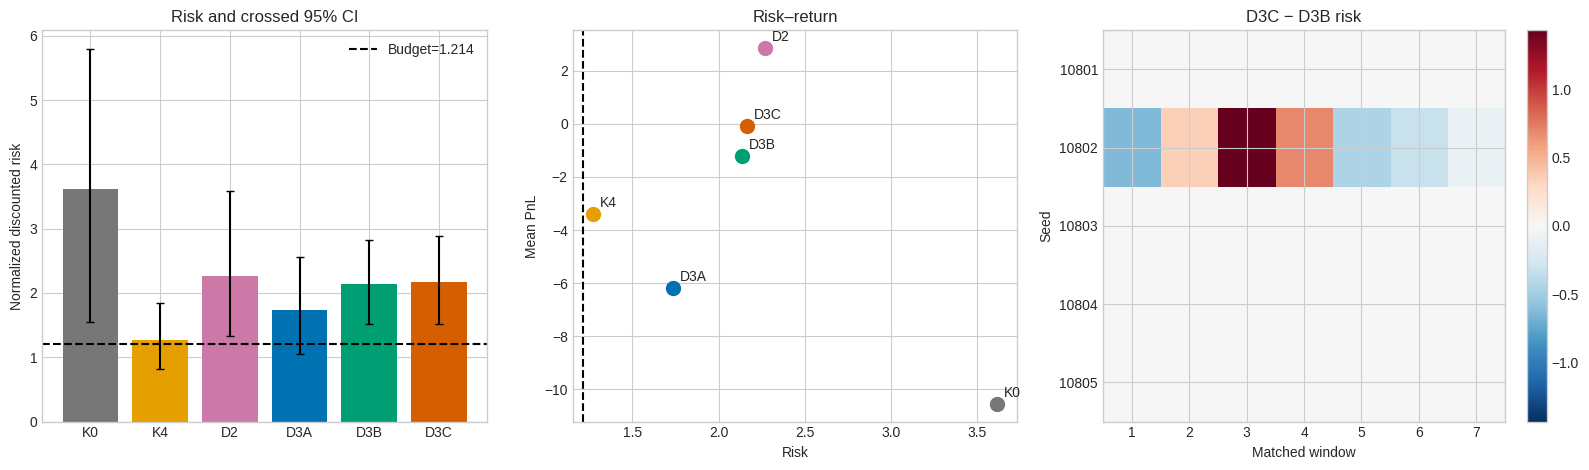

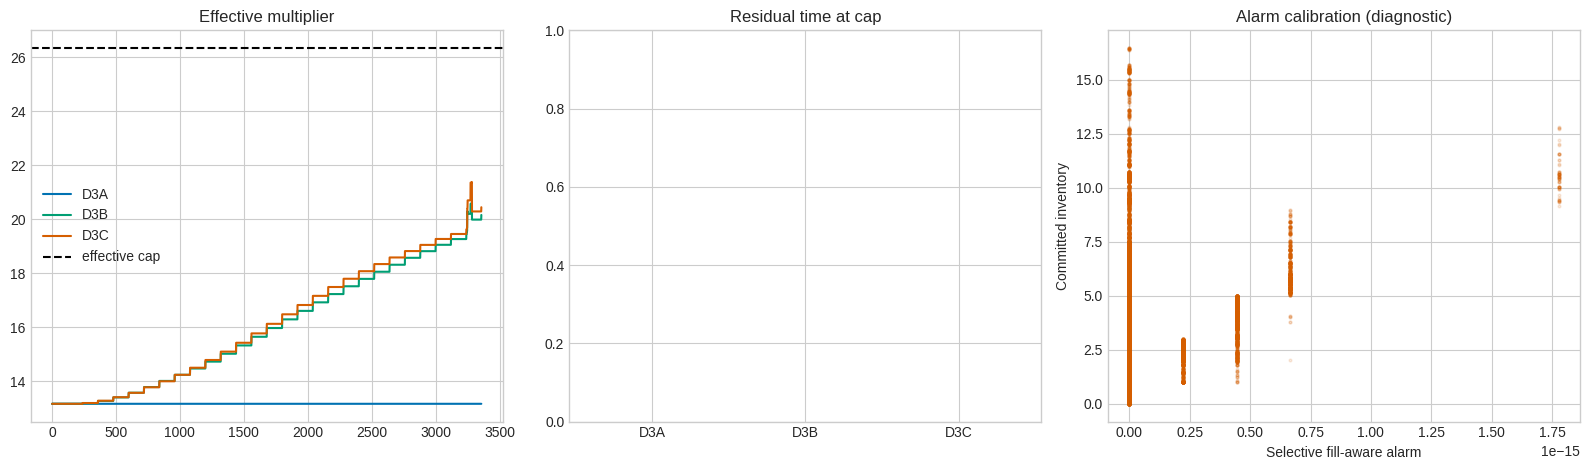

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
colors = {"K0_UNCONSTRAINED":"#777777", "K4_VERY_STRONG":"#E69F00", "D2_ORDER_AWARE_PACING":"#CC79A7",
          CONTROL_LABEL:"#0072B2", PACING_LABEL:"#009E73", PROPOSED_LABEL:"#D55E00"}
short = {"K0_UNCONSTRAINED":"K0", "K4_VERY_STRONG":"K4", "D2_ORDER_AWARE_PACING":"D2",
         CONTROL_LABEL:"D3A", PACING_LABEL:"D3B", PROPOSED_LABEL:"D3C"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8)); x = np.arange(len(REPORT_LABELS))
points=[]; lows=[]; highs=[]
for label in REPORT_LABELS:
    row = inference_df.query("metric == 'absolute_risk' and left == @label and method == 'crossed_iid'").iloc[0]
    points.append(row.point); lows.append(row.point-row.ci_low); highs.append(row.ci_high-row.point)
axes[0].bar(x, points, color=[colors[l] for l in REPORT_LABELS]); axes[0].errorbar(x, points, yerr=[lows, highs], fmt="none", ecolor="black", capsize=3)
axes[0].axhline(TARGET_BUDGET, color="black", ls="--", label=f"Budget={TARGET_BUDGET:.3f}")
axes[0].set_xticks(x, [short[l] for l in REPORT_LABELS]); axes[0].set_ylabel("Normalized discounted risk"); axes[0].set_title("Risk and crossed 95% CI"); axes[0].legend()
for label in REPORT_LABELS:
    row = summary_df[summary_df.label.eq(label)].iloc[0]
    axes[1].scatter(row.risk, row.mean_pnl, s=100, color=colors[label]); axes[1].annotate(short[label], (row.risk,row.mean_pnl), xytext=(5,5), textcoords="offset points")
axes[1].axvline(TARGET_BUDGET, color="black", ls="--"); axes[1].set_xlabel("Risk"); axes[1].set_ylabel("Mean PnL"); axes[1].set_title("Risk–return")
bound=float(np.abs(primary_diff).max()); im=axes[2].imshow(primary_diff, aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
axes[2].set_xticks(range(len(VALIDATION_STARTS)), range(1,len(VALIDATION_STARTS)+1)); axes[2].set_yticks(range(len(MASTER_SEEDS)), MASTER_SEEDS)
axes[2].set_xlabel("Matched window"); axes[2].set_ylabel("Seed"); axes[2].set_title("D3C − D3B risk"); fig.colorbar(im, ax=axes[2], fraction=.046)
fig.tight_layout(); fig.savefig(D3_DIR / "figure1_d3_confirmatory.png", dpi=220, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for label in ARM_LABELS:
    trajectory = d3_transitions[d3_transitions.label.eq(label)].groupby("step").effective_lambda.mean()
    axes[0].plot(trajectory.index, trajectory.values, color=colors[label], label=short[label])
axes[0].axhline(LAMBDA_BASE+RESIDUAL_MAX, color="black", ls="--", label="effective cap"); axes[0].set_title("Effective multiplier"); axes[0].legend()
controller_summary = summary_df[summary_df.label.isin(ARM_LABELS)]
axes[1].bar(range(3), controller_summary.residual_cap_fraction, color=[colors[l] for l in ARM_LABELS]); axes[1].set_xticks(range(3), [short[l] for l in ARM_LABELS]); axes[1].set_ylim(0,1); axes[1].set_title("Residual time at cap")
sample = d3_transitions[d3_transitions.label.eq(PROPOSED_LABEL)].sample(min(25000, len(d3_transitions[d3_transitions.label.eq(PROPOSED_LABEL)])), random_state=SEED)
axes[2].scatter(sample.fill_alarm, sample.committed_inventory_N, s=4, alpha=.12, color=colors[PROPOSED_LABEL]); axes[2].set_xlabel("Selective fill-aware alarm"); axes[2].set_ylabel("Committed inventory"); axes[2].set_title("Alarm calibration (diagnostic)")
fig.tight_layout(); fig.savefig(D3_DIR / "figure2_d3_controller.png", dpi=220, bbox_inches="tight"); plt.show()


In [ ]:
def inf_row(metric, left, right, method="crossed_iid"):
    return inference_df.query("metric == @metric and left == @left and right == @right and method == @method").iloc[0]

proposed_budget = budget_df[budget_df.label.eq(PROPOSED_LABEL)].iloc[0]
proposed_summary = summary_df[summary_df.label.eq(PROPOSED_LABEL)].iloc[0]
d3c_d3b = inf_row("risk_difference", PROPOSED_LABEL, PACING_LABEL)
d3c_d3a = inf_row("risk_difference", PROPOSED_LABEL, CONTROL_LABEL)
d3c_k4 = inf_row("risk_difference", PROPOSED_LABEL, "K4_VERY_STRONG")

budget_gate = bool(proposed_budget.crossed_ci_feasible and proposed_budget.block_ci_feasible)
activity_gate = bool(proposed_summary.activity_ratio_vs_k0 >= D3_CFG["activity_floor_fraction"])
incremental_gate = bool(d3c_d3b.ci_high < 0)
complete_controller_gate = bool(d3c_d3a.ci_high < 0)
signal_gate = bool(0.01 <= proposed_summary.fill_alarm_positive_fraction <= 0.60)
controller_health_gate = bool(proposed_summary.residual_cap_fraction <= D3_CFG["max_residual_cap_fraction"])
fresh_oos_authorized = bool(budget_gate and activity_gate and controller_health_gate and signal_gate and (incremental_gate or complete_controller_gate))

if fresh_oos_authorized:
    route = "FREEZE_D3_AND_AUTHORIZE_ONE_FRESH_OOS_EVALUATION"
elif budget_gate and activity_gate:
    route = "FREEZE_BUDGET_RESULT_INCREMENTAL_ORDER_AWARE_EFFECT_NOT_ESTABLISHED"
elif activity_gate and (d3c_d3b.point < 0 or d3c_d3a.point < 0):
    route = "FREEZE_COMPARATIVE_D3_RESULT_NO_OOS_AUTHORIZATION"
else:
    route = "FREEZE_NEGATIVE_D3_RESULT_NO_OOS_AUTHORIZATION"

confirmed = [
    f"D3C risk={proposed_budget.point:.4f}, crossed CI [{proposed_budget.crossed_ci_low:.4f}, {proposed_budget.crossed_ci_high:.4f}].",
    f"D3C retained {100*proposed_summary.activity_ratio_vs_k0:.2f}% of historical K0 filled notional.",
    f"D3C−D3B risk={d3c_d3b.point:+.4f}, crossed CI [{d3c_d3b.ci_low:.4f}, {d3c_d3b.ci_high:.4f}].",
    f"D3C−D3A risk={d3c_d3a.point:+.4f}, crossed CI [{d3c_d3a.ci_low:.4f}, {d3c_d3a.ci_high:.4f}].",
    f"Residual cap fraction={proposed_summary.residual_cap_fraction:.4f}; selective alarm-positive fraction={proposed_summary.fill_alarm_positive_fraction:.4f}.",
    "No checkpoint reselection, controller retuning, test access or OOS access was performed.",
]
unsupported = [
    "Independent out-of-sample superiority: the seven windows are development validation.",
    "Guaranteed budget compliance outside the frozen evaluation design.",
    "Statistical order-aware superiority unless the D3C−D3B upper CI is below zero.",
    "Live-trading validity or execution-model robustness.",
]
decision = dict(spec_id=SPEC_ID, method_digest=METHOD_DIGEST, proposed_label=PROPOSED_LABEL,
                seeds=len(MASTER_SEEDS), windows_per_seed=len(VALIDATION_STARTS), branch_episodes=BRANCH_EPISODES,
                target_budget=TARGET_BUDGET, proposed_risk=float(proposed_budget.point),
                proposed_crossed_ci=[float(proposed_budget.crossed_ci_low), float(proposed_budget.crossed_ci_high)],
                proposed_block_ci=[float(proposed_budget.block_ci_low), float(proposed_budget.block_ci_high)],
                activity_ratio_vs_k0=float(proposed_summary.activity_ratio_vs_k0), budget_gate=budget_gate,
                activity_gate=activity_gate, incremental_order_aware_gate=incremental_gate,
                complete_controller_gate=complete_controller_gate, signal_gate=signal_gate,
                controller_health_gate=controller_health_gate, fresh_oos_authorized=fresh_oos_authorized,
                checkpoint_reselection_performed=False, controller_retuning_performed=False,
                fixed_penalty_retuning_performed=False, test_used=False, final_route=route,
                confirmed_findings=confirmed, unsupported_claims=unsupported)
atomic_json(decision, D3_DIR / "final_scientific_decision.json")
atomic_csv(pd.DataFrame([decision]), D3_DIR / "final_scientific_decision.csv")

article_md = "# D3 frozen article claims\n\n## Confirmed\n\n" + "\n".join(f"- {x}" for x in confirmed)
article_md += "\n\n## Unsupported\n\n" + "\n".join(f"- {x}" for x in unsupported)
article_md += "\n\n## Final route\n\n`" + route + "`\n"
atomic_text(article_md, D3_DIR / "article_claims.md")
display(pd.DataFrame([decision]))
print("="*88); print("D3 FINAL ROUTE:", route); print("risk / budget:", proposed_budget.point, TARGET_BUDGET)
print("D3C−D3B:", d3c_d3b.point, [d3c_d3b.ci_low, d3c_d3b.ci_high]); print("activity:", proposed_summary.activity_ratio_vs_k0)
print("fresh OOS authorized:", fresh_oos_authorized); print("test used: False"); print("="*88)


,spec_id,method_digest,proposed_label,seeds,windows_per_seed,branch_episodes,target_budget,proposed_risk,proposed_crossed_ci,proposed_block_ci,...,signal_gate,controller_health_gate,fresh_oos_authorized,checkpoint_reselection_performed,controller_retuning_performed,fixed_penalty_retuning_performed,test_used,final_route,confirmed_findings,unsupported_claims
0,v10_d3_fill_aware_residual_dual_20261005,df224d56ef450692b913e0d6bf8b122e718365821c23b5...,D3C_FILL_AWARE_ANTI_WINDUP,5,7,5,1.214222,2.164203,"[1.5138630104707833, 2.89257649727059]","[1.5198970974455817, 2.888896021089971]",...,True,True,False,False,False,False,False,FREEZE_NEGATIVE_D3_RESULT_NO_OOS_AUTHORIZATION,"[D3C risk=2.1642, crossed CI [1.5139, 2.8926]....",[Independent out-of-sample superiority: the se...


D3 FINAL ROUTE: FREEZE_NEGATIVE_D3_RESULT_NO_OOS_AUTHORIZATION
risk / budget: 2.1642026368515324 1.2142215137929977
D3C−D3B: 0.027866670790234752 [np.float64(-0.08761388804859918), np.float64(0.2177888058786549)]
activity: 0.740563181170943
fresh OOS authorized: False
test used: False


In [ ]:
essential_outputs = [
    D3_DIR / "protocol.json", D3_DIR / "fill_calibration_train_only.json",
    D3_DIR / "runtime_manifest.json", D3_DIR / "training_integrity_branch5.csv",
    D3_DIR / "train_only_gradient_diagnostics.csv", D3_DIR / "validation_integrity.csv",
    D3_DIR / "publication_summary.csv", D3_DIR / "budget_compliance.csv",
    D3_DIR / "primary_inference.csv", D3_DIR / "seed_level_primary_ablation.csv",
    D3_DIR / "figure1_d3_confirmatory.png", D3_DIR / "figure2_d3_controller.png",
    D3_DIR / "final_scientific_decision.json", D3_DIR / "article_claims.md",
]
artifact_manifest = pd.DataFrame([
    dict(
        path=str(path.relative_to(PROJECT_ROOT)), exists=path.exists(),
        size_bytes=path.stat().st_size if path.exists() else 0,
        sha256=sha256_file(path) if path.exists() else None,
    )
    for path in essential_outputs
])
if not artifact_manifest["exists"].all():
    raise FileNotFoundError(artifact_manifest.loc[~artifact_manifest["exists"], "path"].tolist())
atomic_csv(artifact_manifest, D3_DIR / "artifact_manifest.csv")
atomic_json(dict(
    spec_id=SPEC_ID, method_digest=METHOD_DIGEST, final_route=route,
    completed=True, test_used=False,
), D3_DIR / "run_complete.json")
display(artifact_manifest)
print("D3 ARTIFACT FREEZE: PASS")


,path,exists,size_bytes,sha256
0,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,2703,d06c99901878df5d02a70db752cf8b51c99e9c32d0a629...
1,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,537,dad593917b4e79a6da84dc019e6ebde0be156d47978337...
2,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,407,b71578be93126f26b1851735ab447e757f07de15a3faa9...
3,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,3049,d0b92e068277e7c34c8178480bc50fd8f237e588bf87f4...
4,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,1562,59448cfaa8ceb7f3de60f6327ade9f229c6c51bd389187...
5,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,129,faeb2d39891e563f0b2473cda602a9552136f74944139c...
6,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,1757,0661c3578af6e0fa4e117492a5e88a210a51c2db71fc81...
7,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,1031,731882a34d0aeb29a50a9e1baf1702bf25a9f82212773c...
8,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,6348,57193e6d197677f4d2731d1eabec7a78f30cbda96767e5...
9,artifacts/risk_budgeted_imm_v10/ETHUSDT/fill_a...,True,337,df2a9a10dc20b4694fd4322140a6f7e861113d24359217...


D3 ARTIFACT FREEZE: PASS


# Reproducibility artifacts

The frozen D3 directory contains the protocol, train-only fill calibration, runtime manifest, training and validation integrity checks, publication tables, primary inference, both figures, the final scientific decision, article claims and an artifact manifest. Gains, bounds, horizons, checkpoints, seeds, windows and decision gates must not be changed after validation is opened. Every final route, including a negative or nuanced route, is a valid frozen scientific outcome.
